In [2]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))
from utils import get_spike_activity, sdf, sdf_mean
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [9]:
ratio = 50
rooth_path = f"/home/csartor1/code/NODS/results/plus_area_{ratio}/"
with open("/home/csartor1/code/NODS/network_configuration.json", "r") as json_file:
    net_config = json.load(json_file)

CS_burst_dur = net_config["devices"]["CS"]["parameters"]["burst_dur"]
CS_start_first = float(net_config["devices"]["CS"]["parameters"]["start_first"])
between_start = net_config["devices"]["CS"]["parameters"]["between_start"]
n_trials = net_config["devices"]["CS"]["parameters"]["n_trials"]
US_start_first = float(net_config["devices"]["US"]["parameters"]["start_first"])

cell_color = net_config["cell_types"]["purkinje_cell"]["color"][0]
CS_color = net_config["colors"]["CS"]
US_color = net_config["colors"]["US"]
with_NO_color = net_config["devices"]["nNOS"]["color"][0]
without_NO_color = "#000000"

In [10]:
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))

In [5]:
cell = "pc_spikes"
result_path = rooth_path+"wo_NO/4Hz/"

sdf_mean_trials_simulations = []
sdf_mean_cell = []
for k in range(5):
    file_path = result_path+ f"sim_{k+1}/"
    print(f"sim_{k+1}", flush=True)
    sdf_mean_over_trials = []
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0]
    intervals = [(500,1000), (14500,15000)]

    for start, end in intervals:
        mask = (times >= start) & (times <= end)
        filtered_times = times[mask]
        filtered_ids = ID_cell[mask]

    # Convert results back to numpy arrays for consistency
        filtered_times = np.array(filtered_times)
        filtered_ids = np.array(filtered_ids)

        plt.figure()
        plt.axvline(CS_start_first+start, label="CS start", linewidth=3, c=CS_color)
        plt.axvline(US_start_first - between_start + start, label="US start", linewidth=3, c=US_color)
        plt.axvline(CS_start_first + CS_burst_dur + start, label="CS & US end ", linewidth=3, c="#E1D5E7")
        plt.scatter(filtered_times,filtered_ids, s = 1)
        plt.title(f"standard STDP trial {int(end/500)}")
        plt.ylabel("SDF [Hz]")
        plt.xlabel("Time [ms]")
        plt.legend()
        plt.show()


sim_1


FileNotFoundError: [Errno 2] No such file or directory: '/home/csartor1/code/NODS/results/plus_area_50wo_NO/4Hz/sim_1/'

sim_1


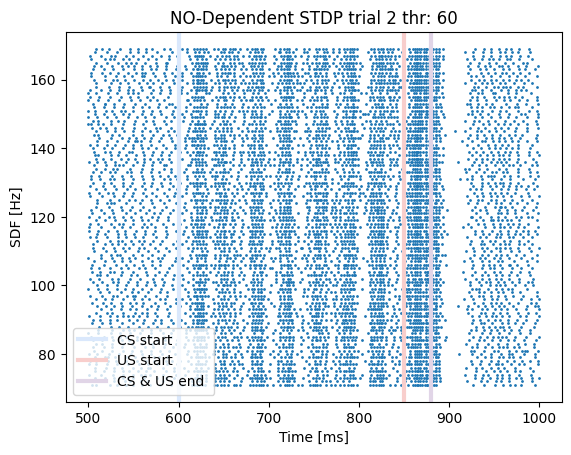

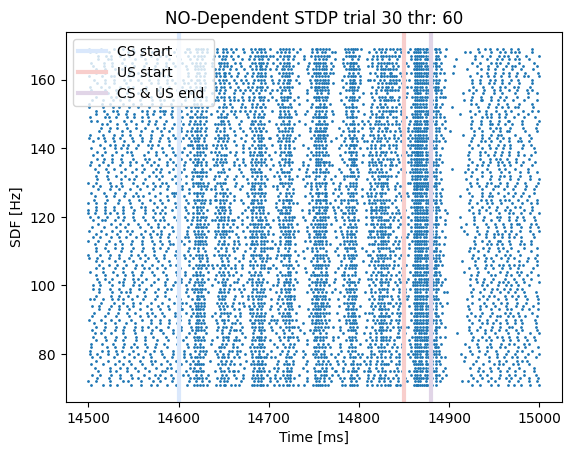

sim_2


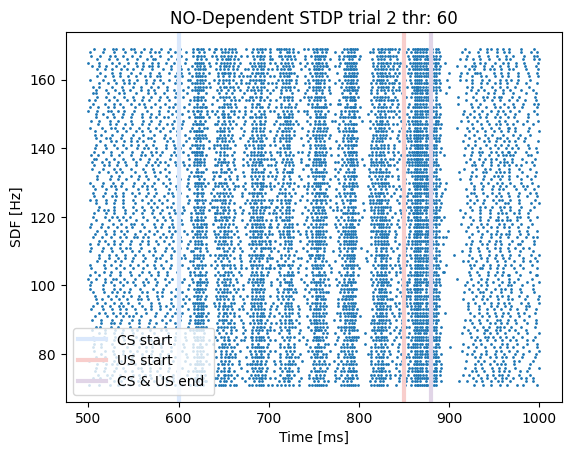

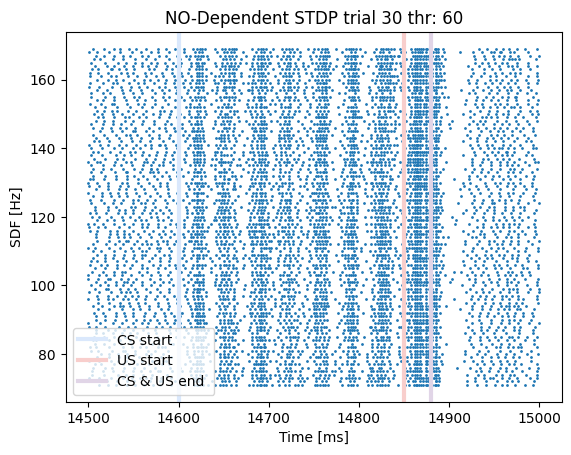

sim_3


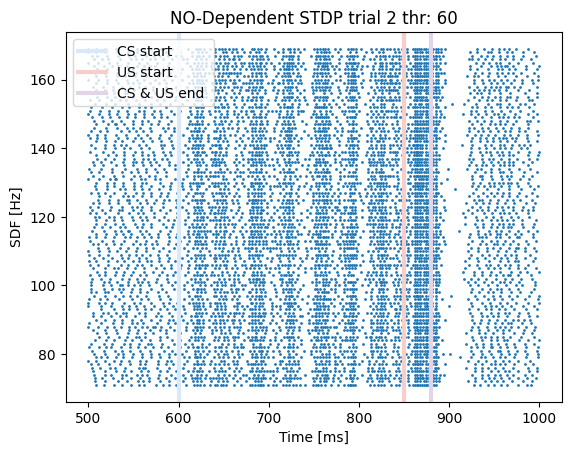

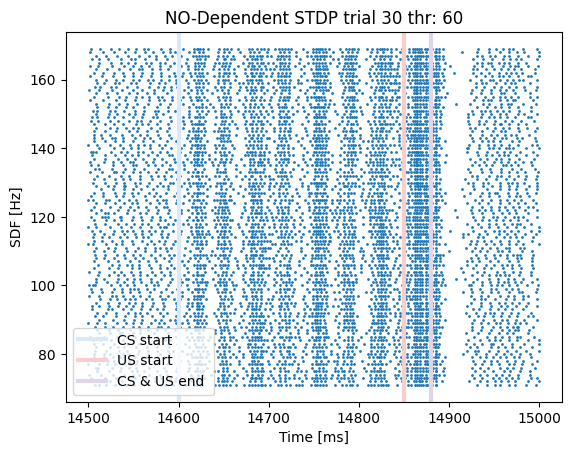

sim_4


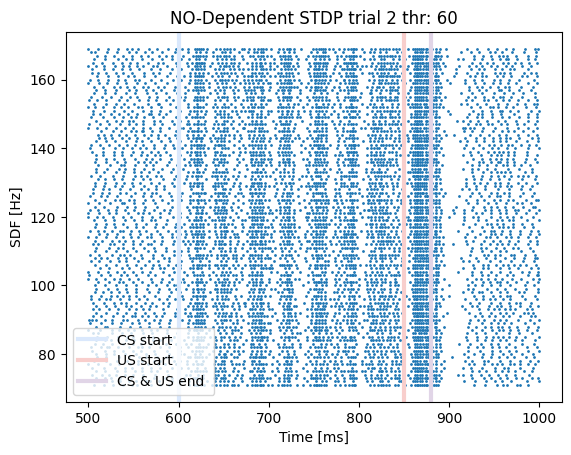

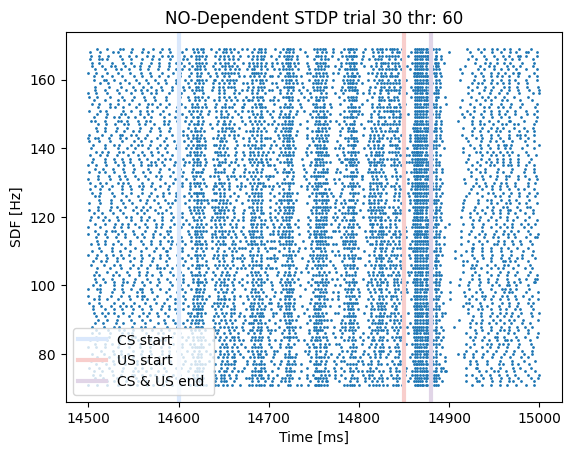

sim_5


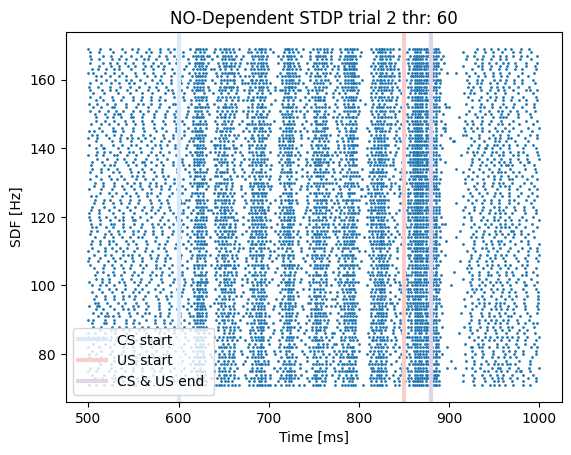

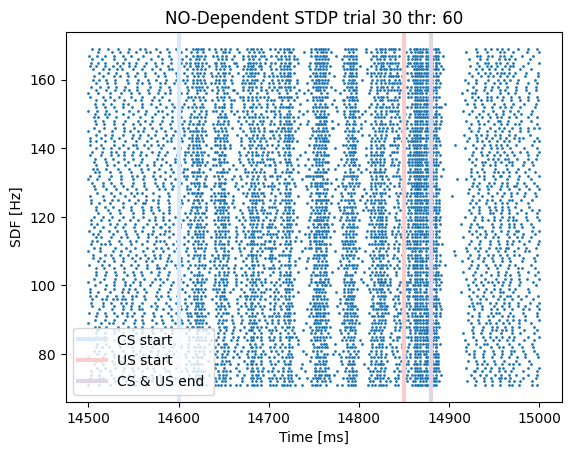

In [5]:
cell = "pc_spikes"
result_path = rooth_path+"test/thr_60/"

sdf_mean_trials_simulations = []
sdf_mean_cell = []
for k in range(5):
    file_path = result_path+ f"sim_{k+1}/"
    print(f"sim_{k+1}", flush=True)
    sdf_mean_over_trials = []
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0]
    intervals = [(500,1000), (14500,15000)]

    for start, end in intervals:
        mask = (times >= start) & (times <= end)
        filtered_times = times[mask]
        filtered_ids = ID_cell[mask]

    # Convert results back to numpy arrays for consistency
        filtered_times = np.array(filtered_times)
        filtered_ids = np.array(filtered_ids)

        plt.figure()
        plt.axvline(CS_start_first+start, label="CS start", linewidth=3, c=CS_color)
        plt.axvline(US_start_first - between_start + start, label="US start", linewidth=3, c=US_color)
        plt.axvline(CS_start_first + CS_burst_dur + start, label="CS & US end ", linewidth=3, c="#E1D5E7")
        plt.scatter(filtered_times,filtered_ids, s = 1)
        plt.title(f"NO-Dependent STDP trial {int(end/500)} thr: 60")
        plt.ylabel("SDF [Hz]")
        plt.xlabel("Time [ms]")
        plt.legend()
        plt.show()

sim_1


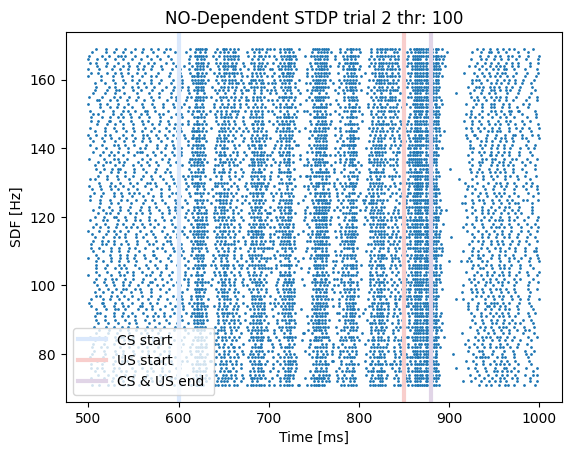

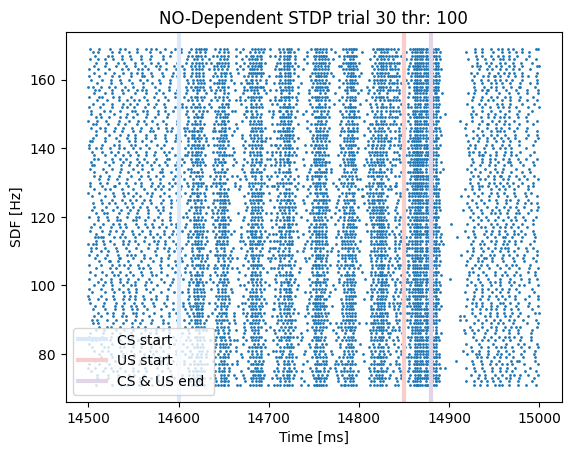

sim_2


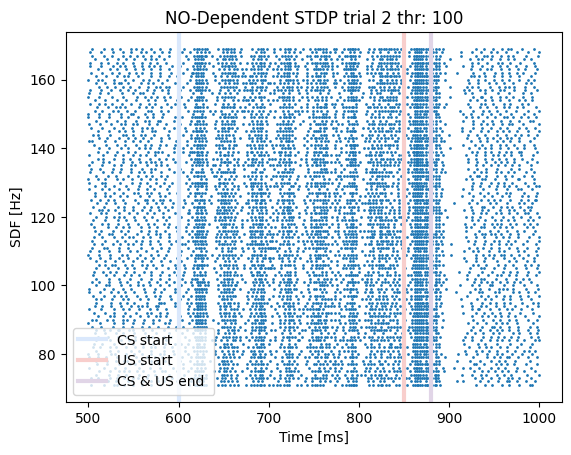

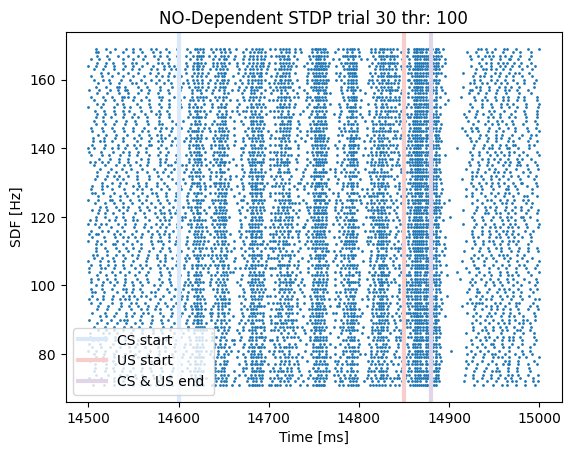

sim_3


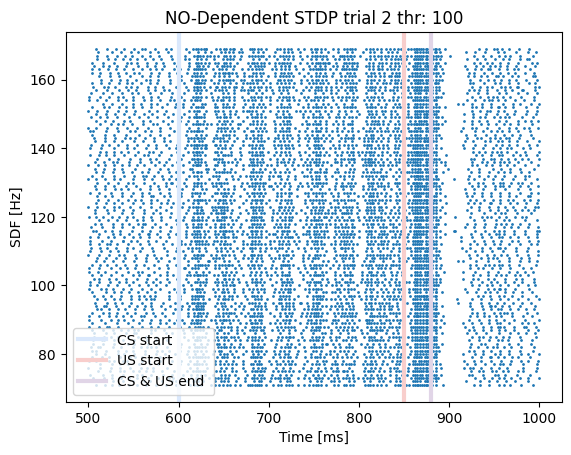

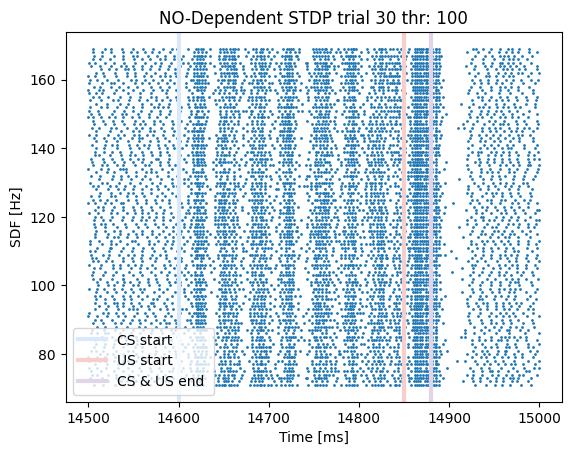

sim_4


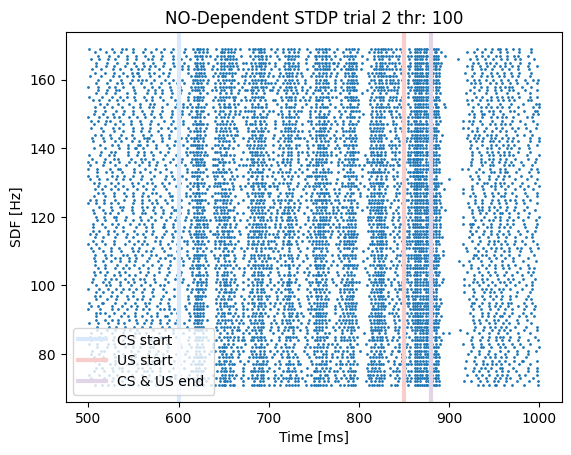

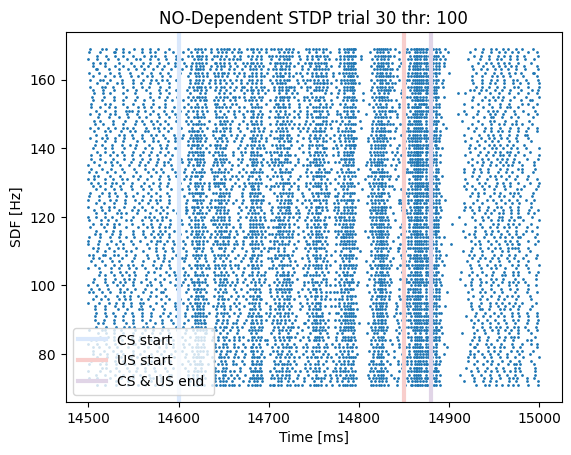

sim_5


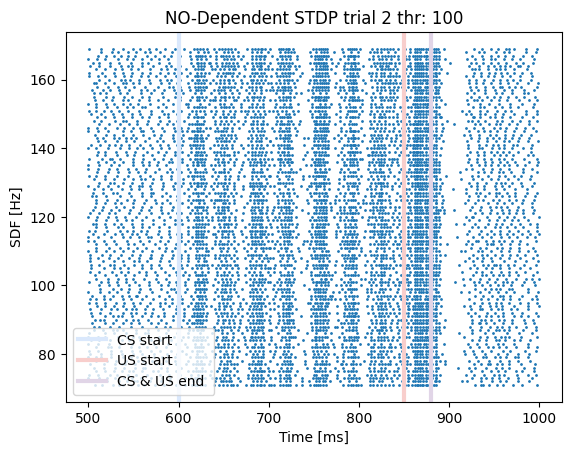

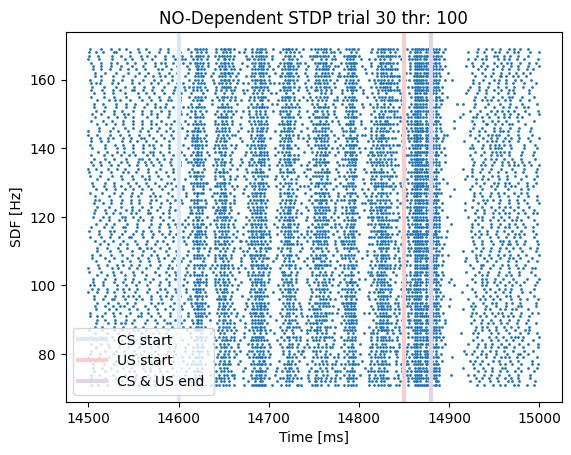

In [6]:
cell = "pc_spikes"
result_path = rooth_path+"test/thr_100/"

sdf_mean_trials_simulations = []
sdf_mean_cell = []
for k in range(5):
    file_path = result_path+ f"sim_{k+1}/"
    print(f"sim_{k+1}", flush=True)
    sdf_mean_over_trials = []
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0]
    intervals = [(500,1000), (14500,15000)]

    for start, end in intervals:
        mask = (times >= start) & (times <= end)
        filtered_times = times[mask]
        filtered_ids = ID_cell[mask]

    # Convert results back to numpy arrays for consistency
        filtered_times = np.array(filtered_times)
        filtered_ids = np.array(filtered_ids)

        plt.figure()
        plt.axvline(CS_start_first+start, label="CS start", linewidth=3, c=CS_color)
        plt.axvline(US_start_first - between_start + start, label="US start", linewidth=3, c=US_color)
        plt.axvline(CS_start_first + CS_burst_dur + start, label="CS & US end ", linewidth=3, c="#E1D5E7")
        plt.scatter(filtered_times,filtered_ids, s = 1)
        plt.title(f"NO-Dependent STDP trial {int(end/500)} thr: 100")
        plt.ylabel("SDF [Hz]")
        plt.xlabel("Time [ms]")
        plt.legend()
        plt.show()

In [11]:
# heatmaps of number of spikes for every PC
cell = 'pc_spikes'
time_bin = 50
trial_len = between_start
n_sim = 5
pc_ids = np.arange(71,170)

In [13]:
result_path = rooth_path+"wo_NO/4Hz/"
pc_spikes_matrix_trial_2 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_30 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_diff = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
trial_len = between_start
for k in range(0,n_sim):
    file_path = result_path+f'sim_{k}/'
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0].astype(int)

    intervals = [(500,1000), (14500,15000)]
    for i,interval in enumerate(intervals):
        for j,t_interval in enumerate(range(interval[0],interval[1],time_bin)):
            start = t_interval
            end = t_interval+time_bin
            mask = (times >= start) & (times <= end)
            filtered_ids = ID_cell[mask]


            for id in np.unique(filtered_ids):
                count_spikes = len(np.where(filtered_ids==id)[0])
                ind_pc_id = np.where(pc_ids == id)[0]
                if i == 0:
                    pc_spikes_matrix_trial_2[ind_pc_id,j,k] = count_spikes
                else:
                    pc_spikes_matrix_trial_30[ind_pc_id,j,k] = count_spikes

pc_spikes_matrix_trial_30 = np.median(pc_spikes_matrix_trial_30,axis = 2)
pc_spikes_matrix_trial_2 = np.median(pc_spikes_matrix_trial_2,axis = 2)
pc_spikes_matrix_trial_diff = pc_spikes_matrix_trial_30 - pc_spikes_matrix_trial_2

/tmp/ipykernel_280565/2442724567.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


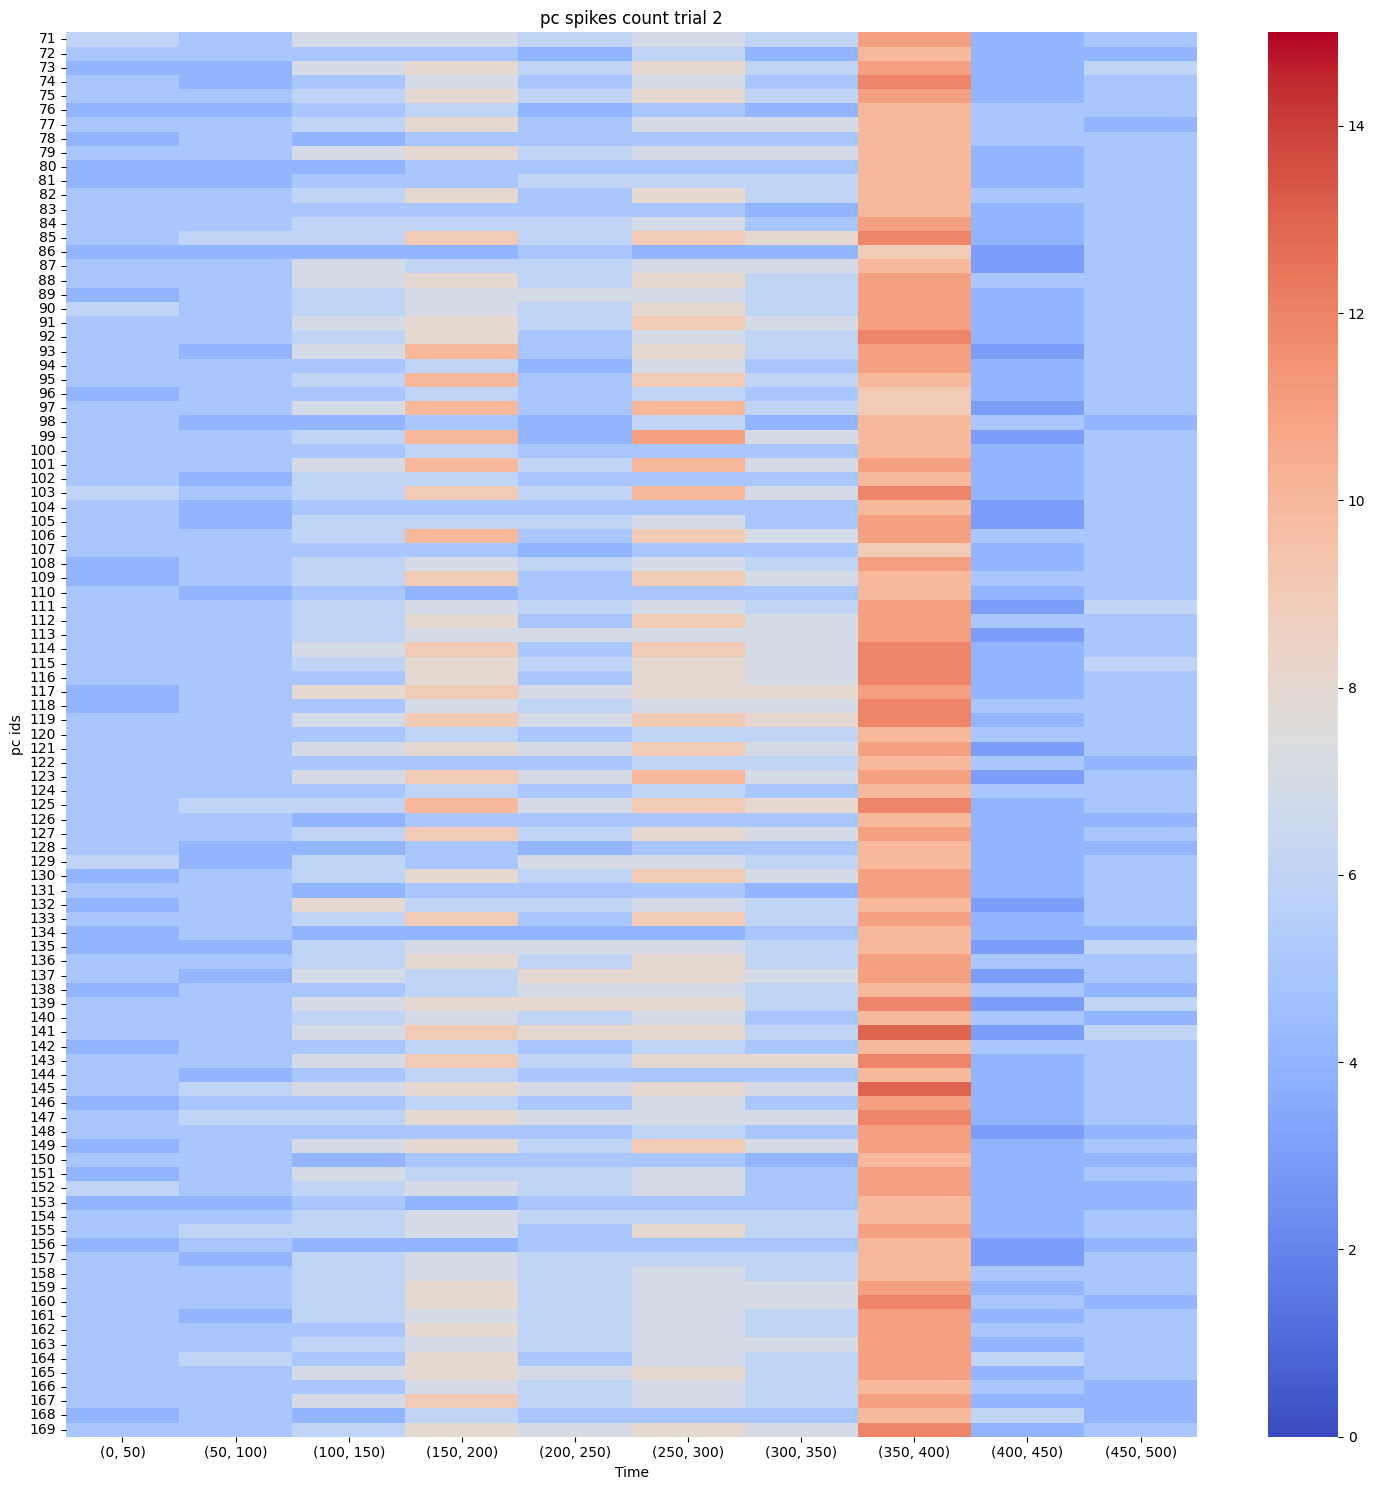

In [14]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_2, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 2')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_2')


/tmp/ipykernel_219130/768584616.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


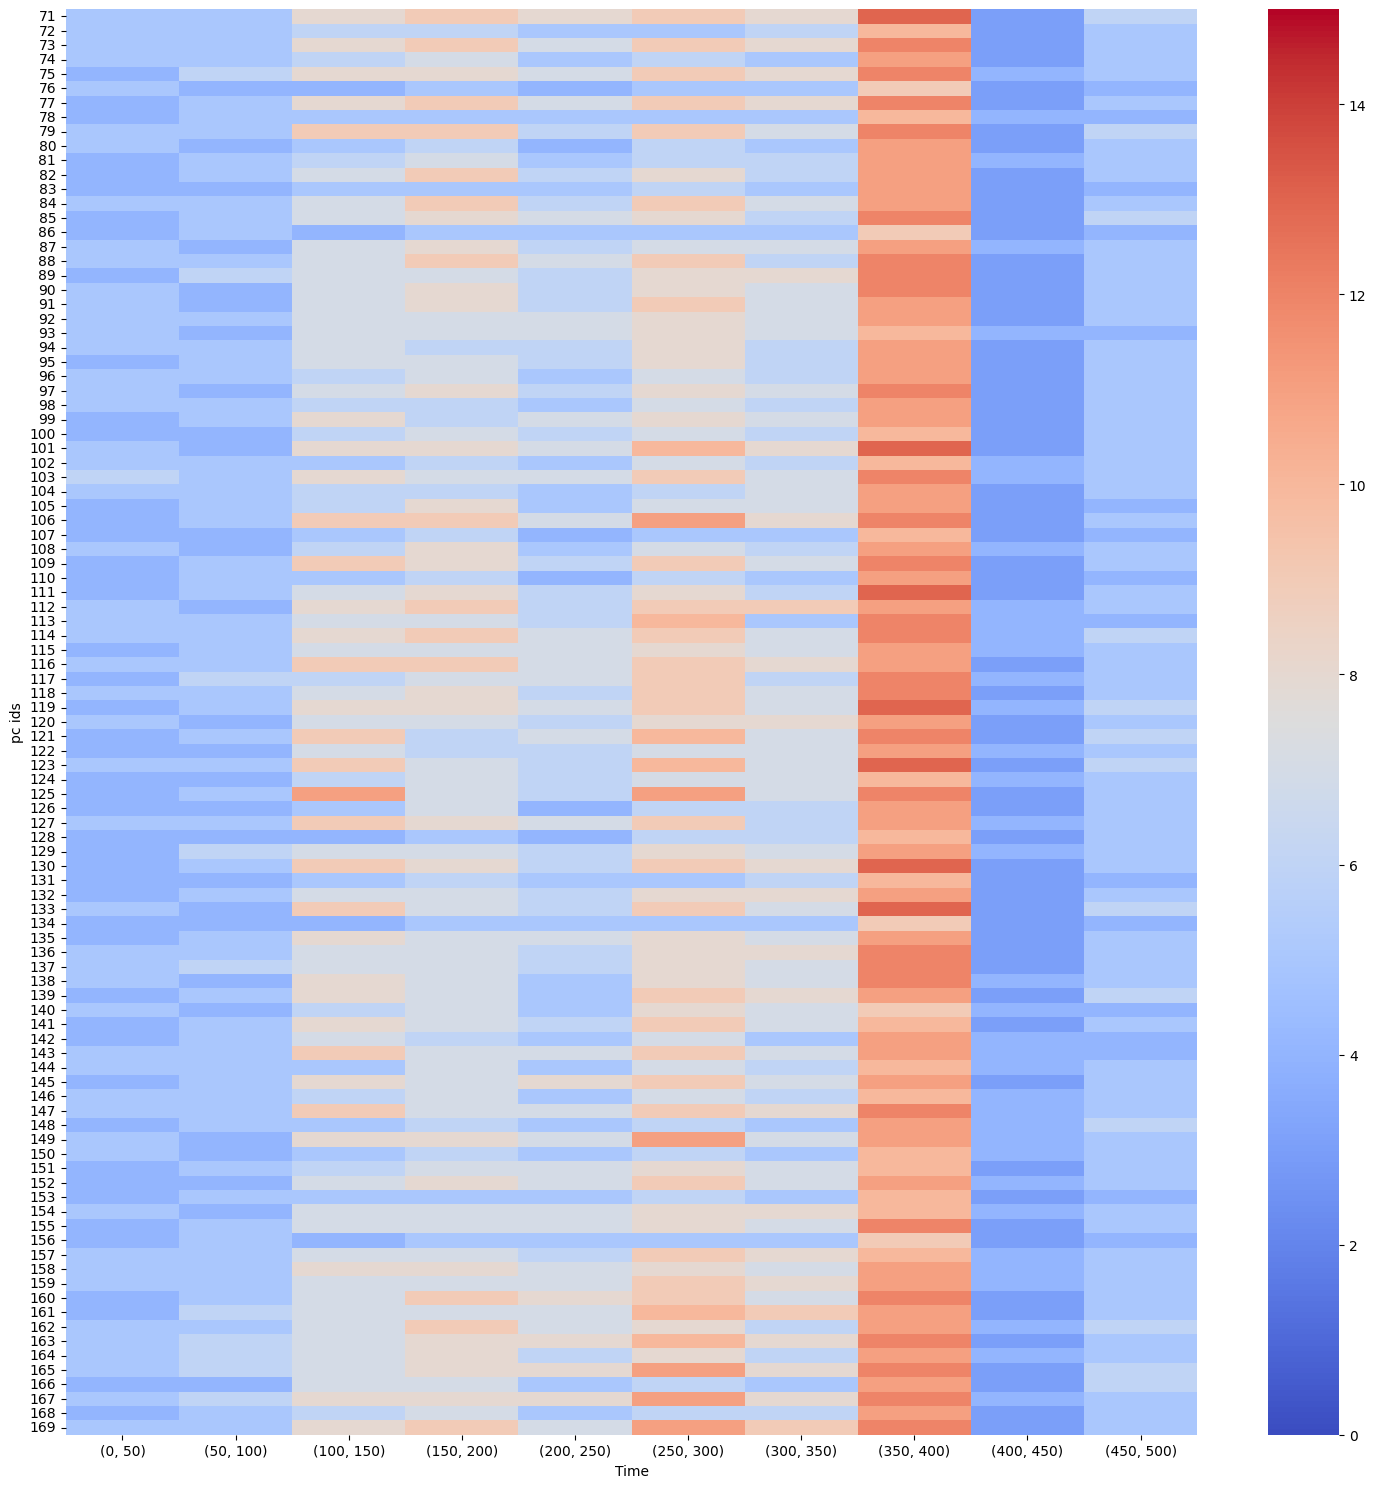

In [10]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_30, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_30')

/tmp/ipykernel_219130/1369467128.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


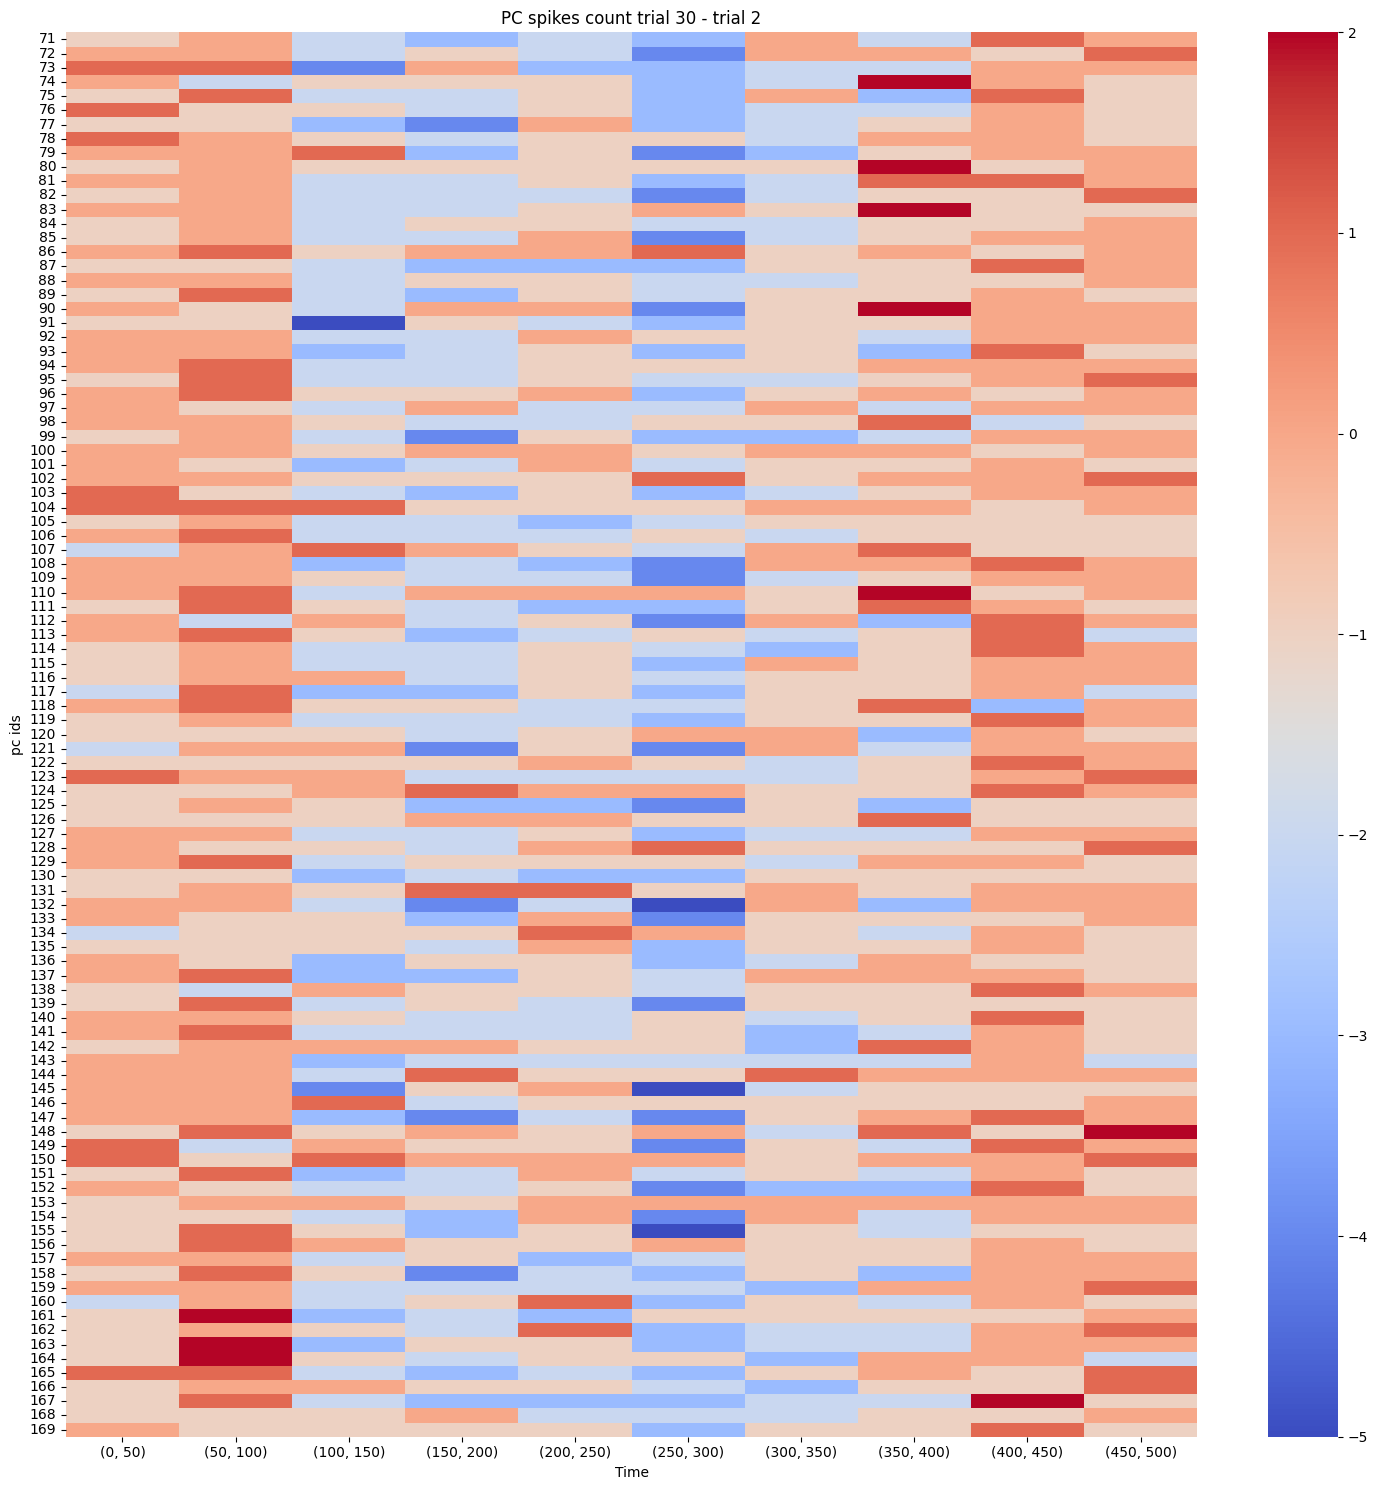

In [11]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_diff, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = -5,
            vmax = 2
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count trial 30 - trial 2')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff')

In [12]:
pc_change = np.zeros((len(pc_ids),3))
for i in range(3):
    pc_change[:,i] = pc_spikes_matrix_trial_diff[:,5]-pc_spikes_matrix_trial_diff[:,2+i]

pc_change_median = pc_spikes_matrix_trial_diff[:,5] - np.median(pc_spikes_matrix_trial_diff[:,2:5], axis =1)
pc_change_cr_bs = pc_spikes_matrix_trial_diff[:,5] - pc_spikes_matrix_trial_diff[:,3]

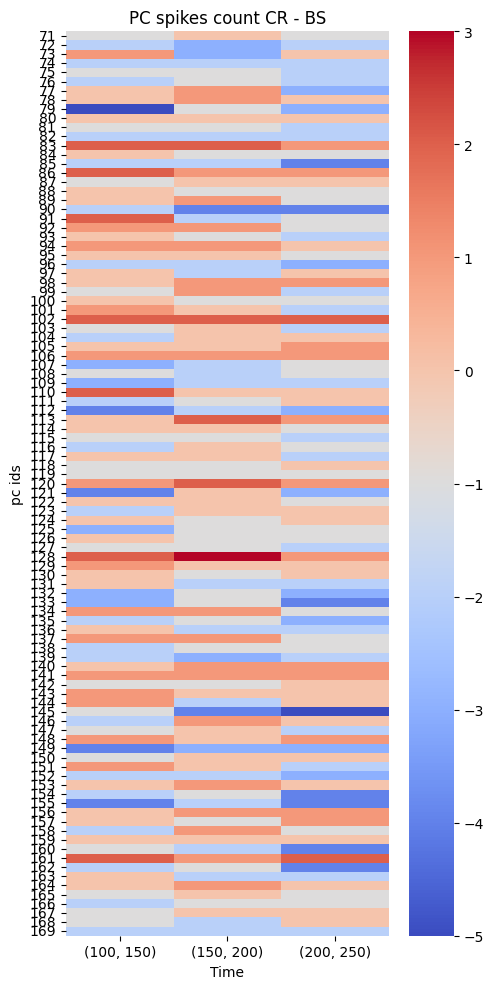

In [13]:
plt.figure(figsize=(5,10))
sns.heatmap(pc_change, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(100,250,time_bin)], 
            yticklabels=pc_ids,
            vmin = -5,
            vmax = 3
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count CR - BS')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff')

In [15]:
# heatmaps of number of spikes for every PC
result_path = rooth_path+"test/thr_60/"
pc_spikes_matrix_trial_2_60 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_30_60 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_diff_60 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
trial_len = between_start
for k in range(0,n_sim):
    file_path = result_path+f'sim_{k}/'
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0].astype(int)

    intervals = [(500,1000), (14500,15000)]
    for i,interval in enumerate(intervals):
        for j,t_interval in enumerate(range(interval[0],interval[1],time_bin)):
            start = t_interval
            end = t_interval+time_bin
            mask = (times >= start) & (times <= end)
            filtered_ids = ID_cell[mask]


            for id in np.unique(filtered_ids):
                count_spikes = len(np.where(filtered_ids==id)[0])
                ind_pc_id = np.where(pc_ids == id)[0]
                if i == 0:
                    pc_spikes_matrix_trial_2_60[ind_pc_id,j,k] = count_spikes
                else:
                    pc_spikes_matrix_trial_30_60[ind_pc_id,j,k] = count_spikes

pc_spikes_matrix_trial_30_60 = np.median(pc_spikes_matrix_trial_30_60,axis = 2)
pc_spikes_matrix_trial_2_60 = np.median(pc_spikes_matrix_trial_2_60,axis = 2)
pc_spikes_matrix_trial_diff_60 = pc_spikes_matrix_trial_30_60 - pc_spikes_matrix_trial_2_60

FileNotFoundError: [Errno 2] No such file or directory: '/home/csartor1/code/NODS/results/plus_area_50/test/thr_60/sim_0/'

/tmp/ipykernel_219130/3419147920.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


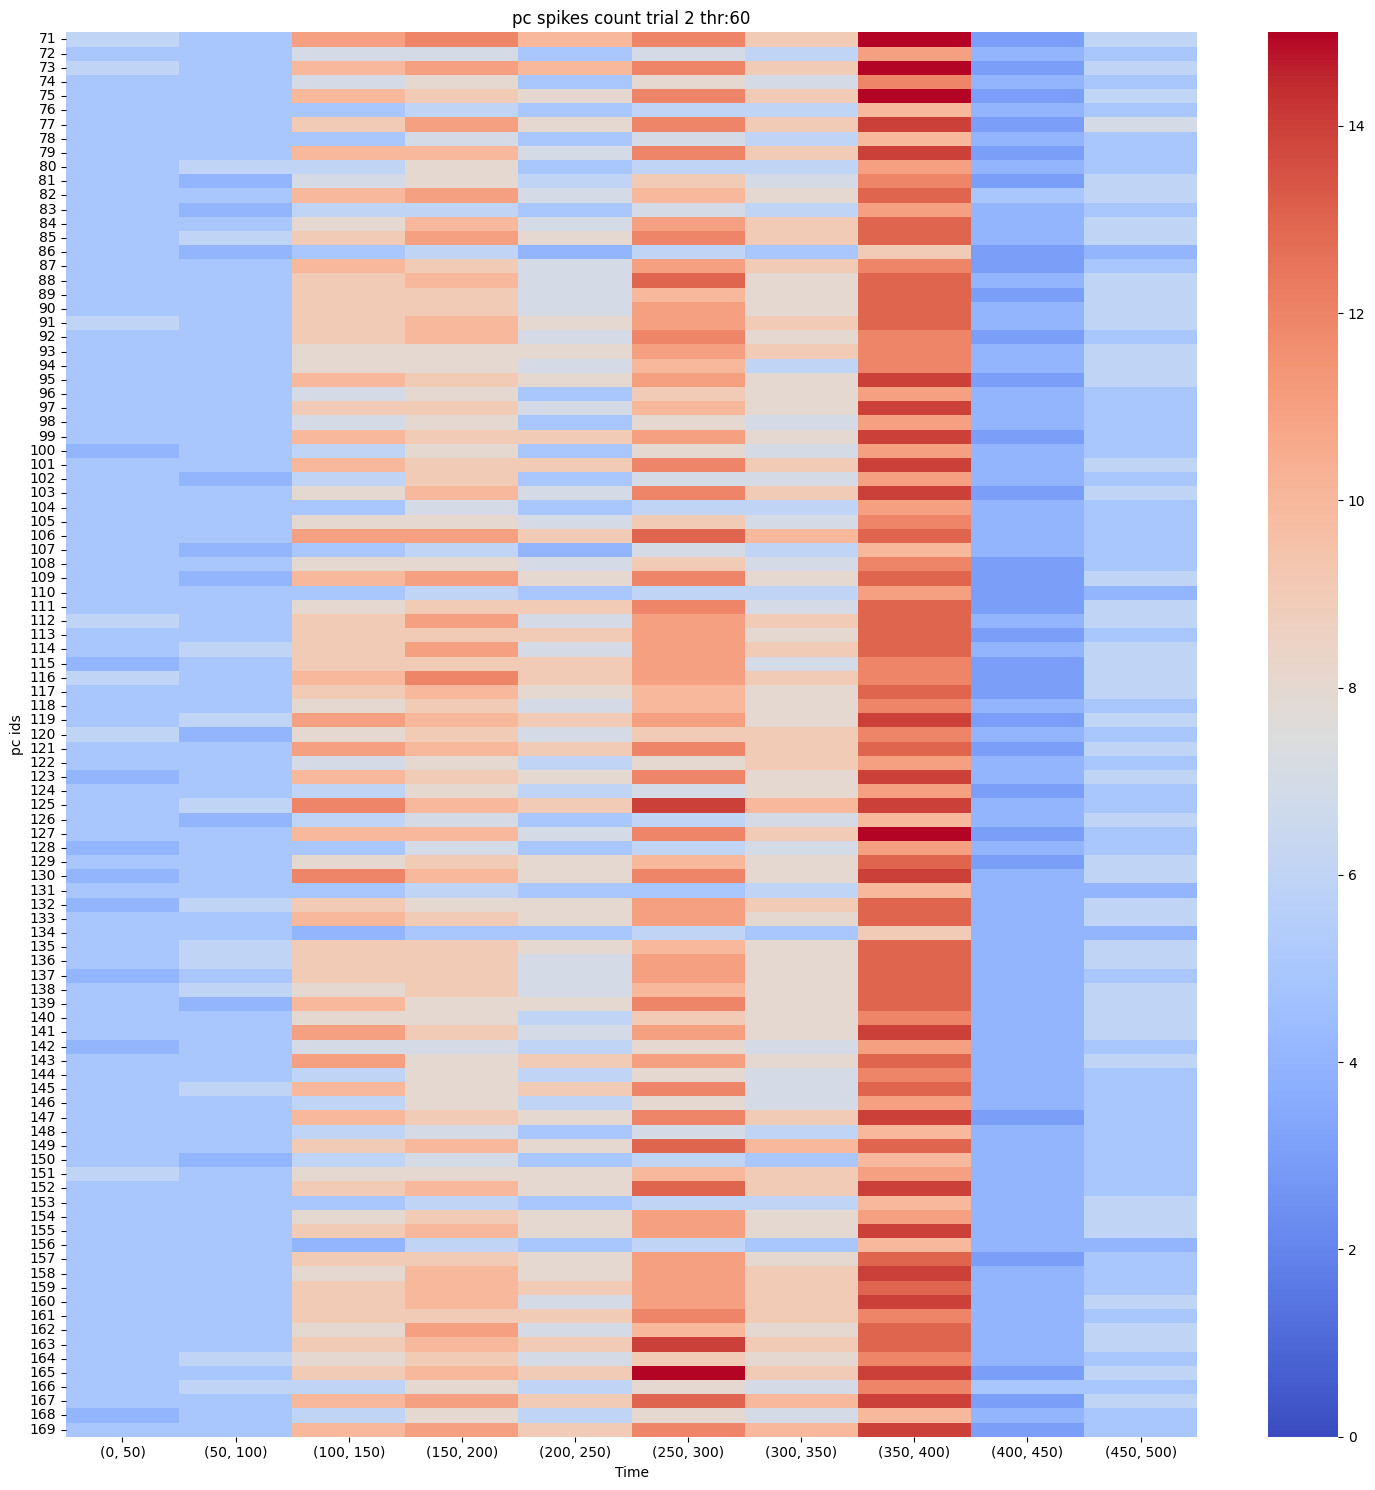

In [15]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_2_60, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 2 thr:60')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_2_thr60')

/tmp/ipykernel_219130/3095577329.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


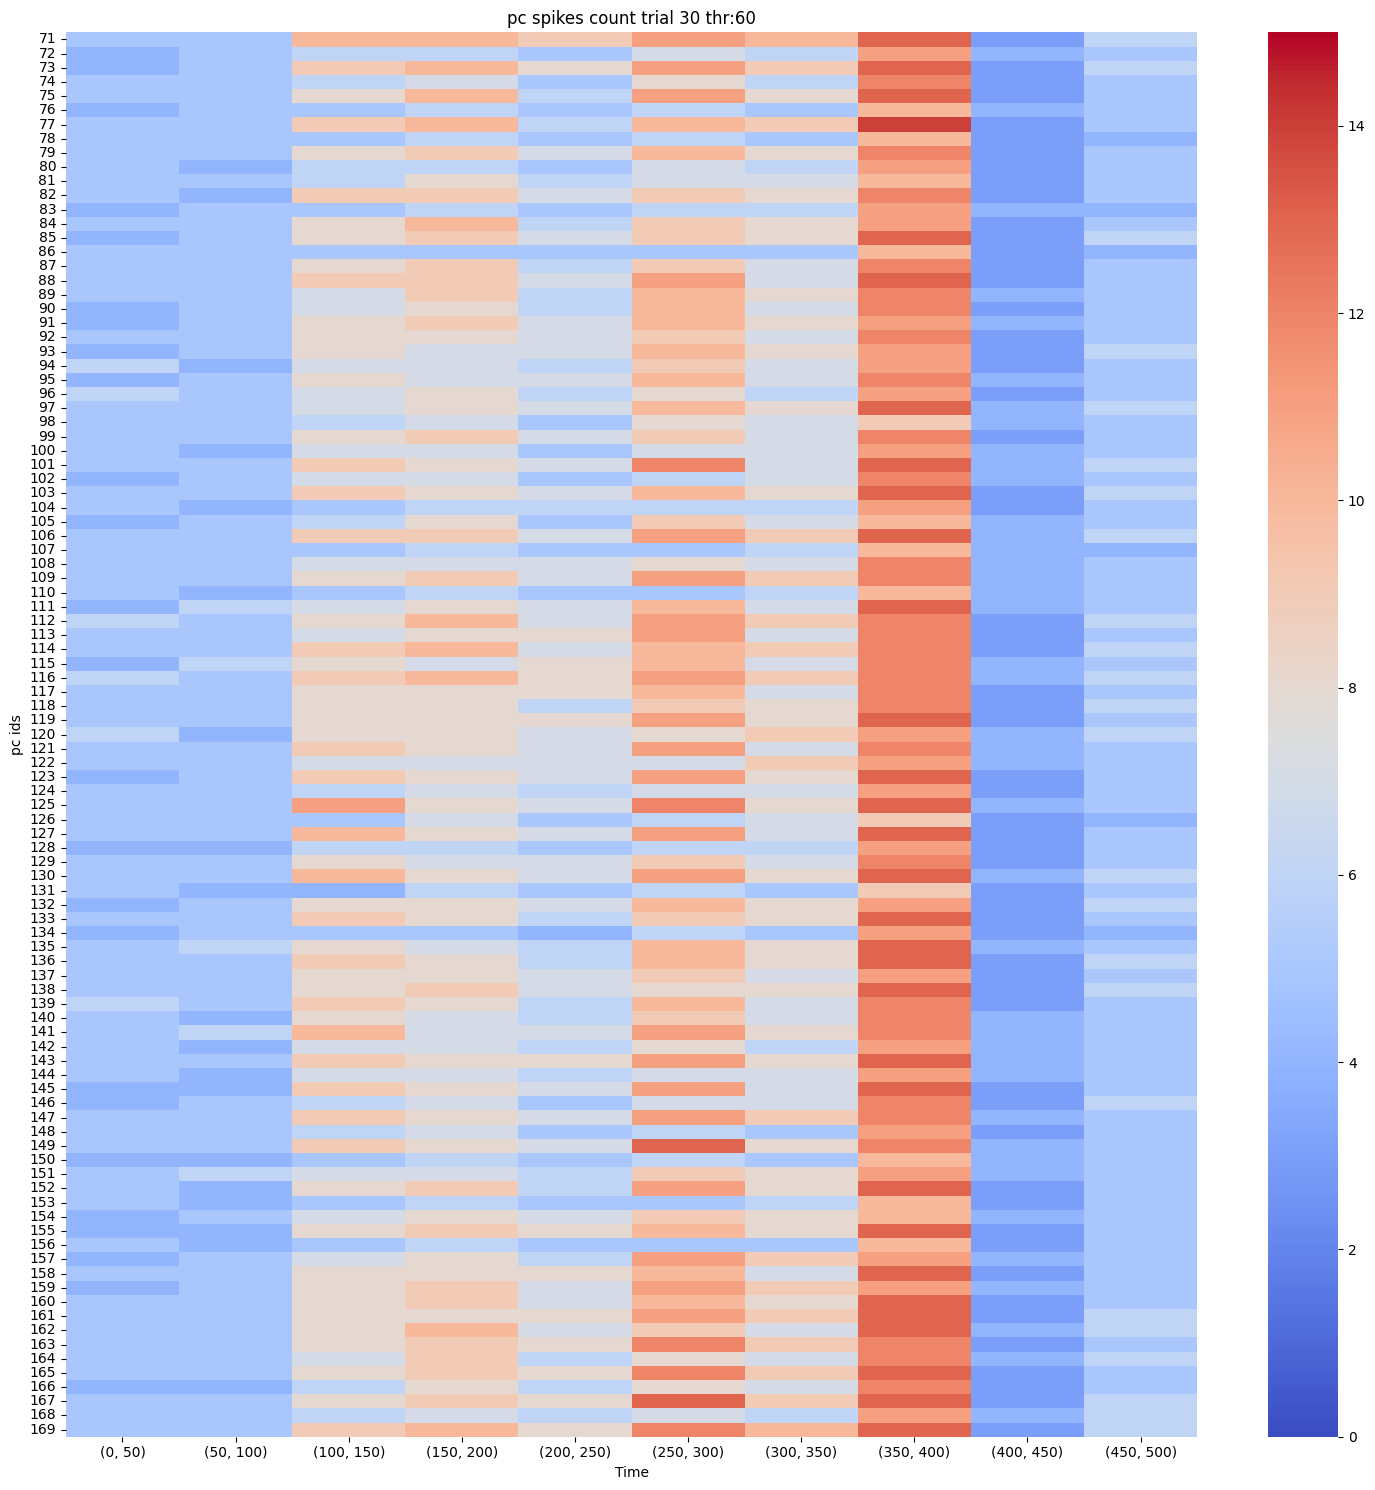

In [16]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_30_60, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 30 thr:60')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_30_thr_60')

/tmp/ipykernel_219130/2601428579.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


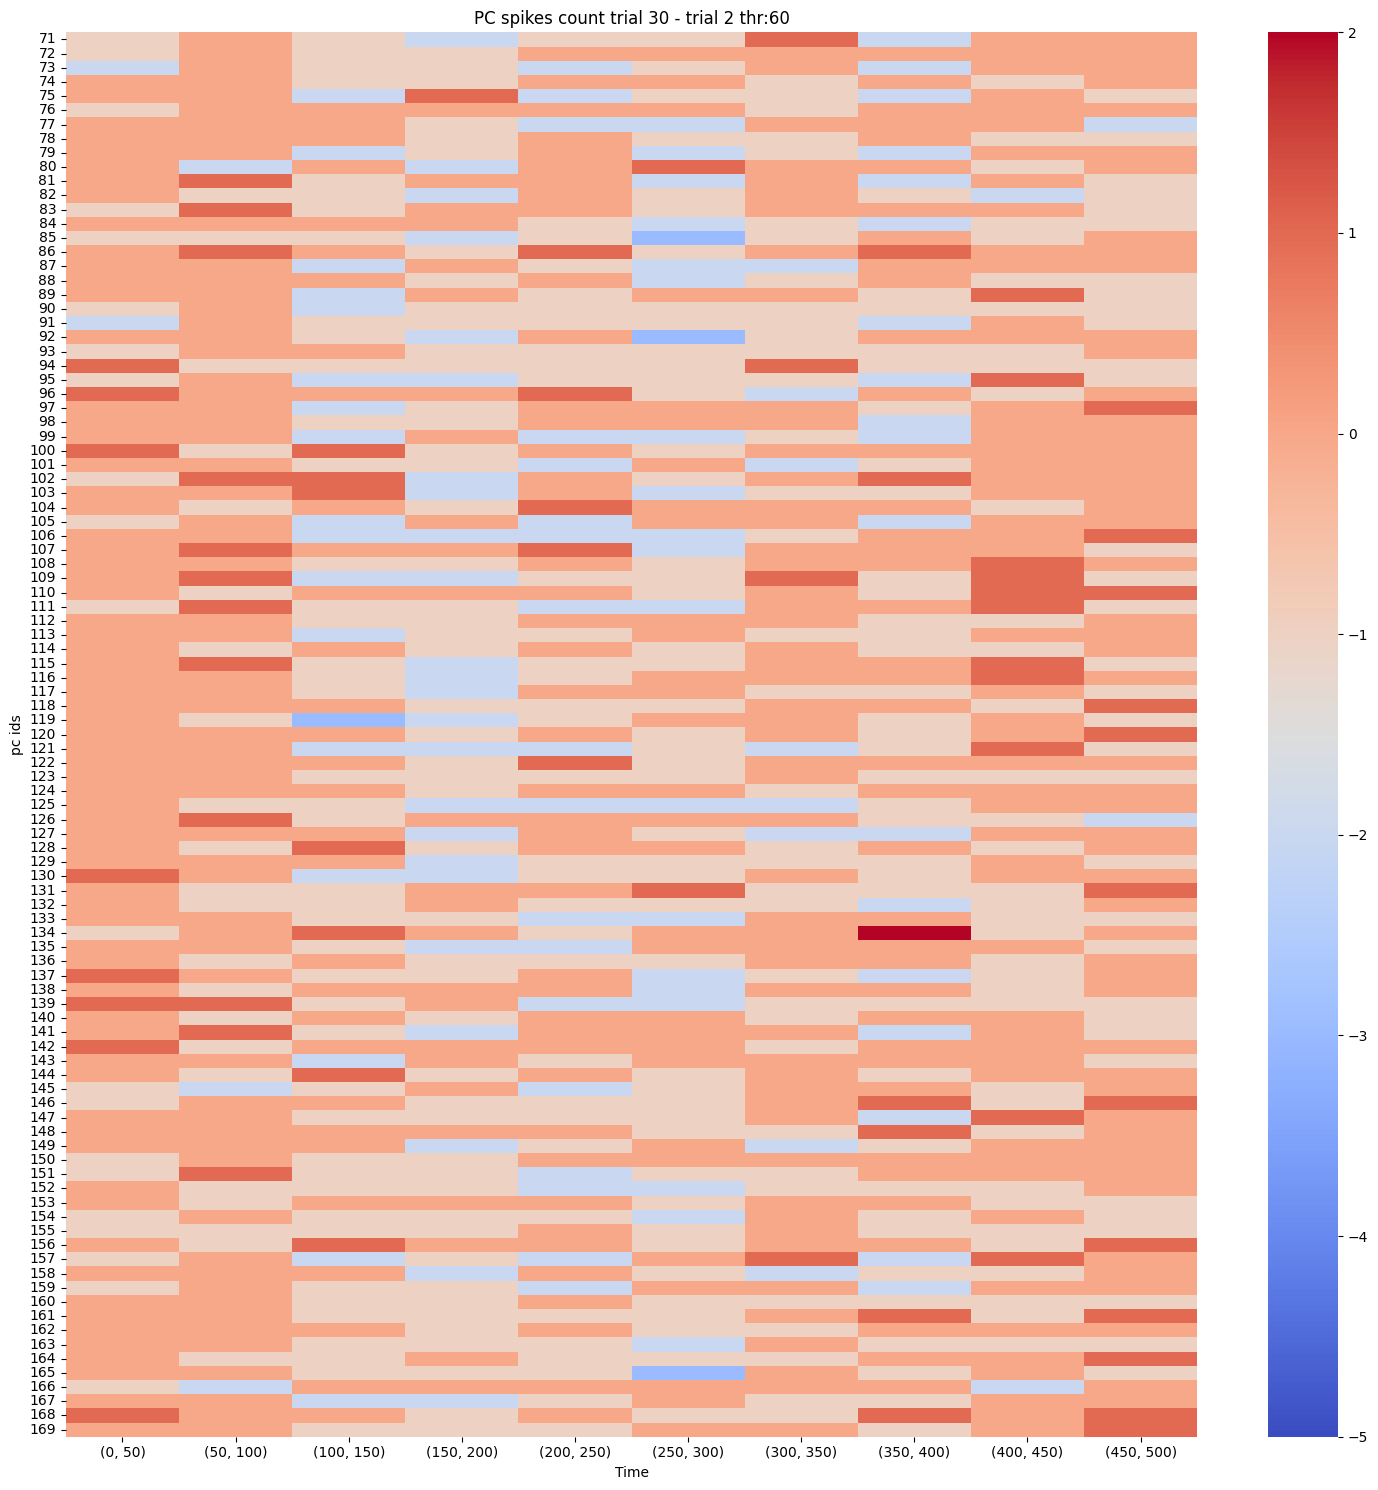

In [17]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_diff_60, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmax = 2,
            vmin = -5
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count trial 30 - trial 2 thr:60' )
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff_thr60')

In [18]:
pc_change_60 = np.zeros((len(pc_ids),3))
for i in range(3):
    pc_change_60[:,i] = pc_spikes_matrix_trial_diff_60[:,5]-pc_spikes_matrix_trial_diff_60[:,2+i]

pc_change_median_60 = pc_spikes_matrix_trial_diff_60[:,5] - np.median(pc_spikes_matrix_trial_diff_60[:,2:5], axis =1)
pc_change_cr_bs_60 = pc_spikes_matrix_trial_diff_60[:,5] - pc_spikes_matrix_trial_diff_60[:,3]

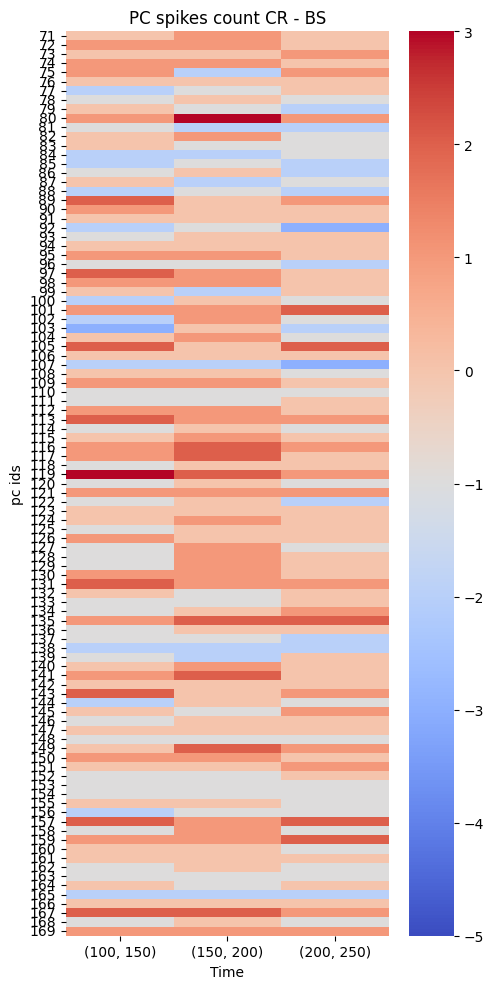

In [19]:
plt.figure(figsize=(5,10))
sns.heatmap(pc_change_60, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(100,250,time_bin)], 
            yticklabels=pc_ids,
            vmin = -5,
            vmax = 3
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count CR - BS')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff')

In [20]:
# heatmaps of number of spikes for every PC
result_path = rooth_path+"test/thr_100/"
pc_spikes_matrix_trial_2_100 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_30_100 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_diff_100 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
trial_len = between_start
for k in range(0,n_sim):
    file_path = result_path+f'sim_{k+1}/'
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0].astype(int)

    intervals = [(500,1000), (14500,15000)]
    for i,interval in enumerate(intervals):
        for j,t_interval in enumerate(range(interval[0],interval[1],time_bin)):
            start = t_interval
            end = t_interval+time_bin
            mask = (times >= start) & (times <= end)
            filtered_ids = ID_cell[mask]


            for id in np.unique(filtered_ids):
                count_spikes = len(np.where(filtered_ids==id)[0])
                ind_pc_id = np.where(pc_ids == id)[0]
                if i == 0:
                    pc_spikes_matrix_trial_2_100[ind_pc_id,j,k] = count_spikes
                else:
                    pc_spikes_matrix_trial_30_100[ind_pc_id,j,k] = count_spikes

pc_spikes_matrix_trial_30_100 = np.median(pc_spikes_matrix_trial_30_100,axis = 2)
pc_spikes_matrix_trial_2_100 = np.median(pc_spikes_matrix_trial_2_100,axis = 2)
pc_spikes_matrix_trial_diff_100 = pc_spikes_matrix_trial_30_100 - pc_spikes_matrix_trial_2_100

/tmp/ipykernel_219130/344713318.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


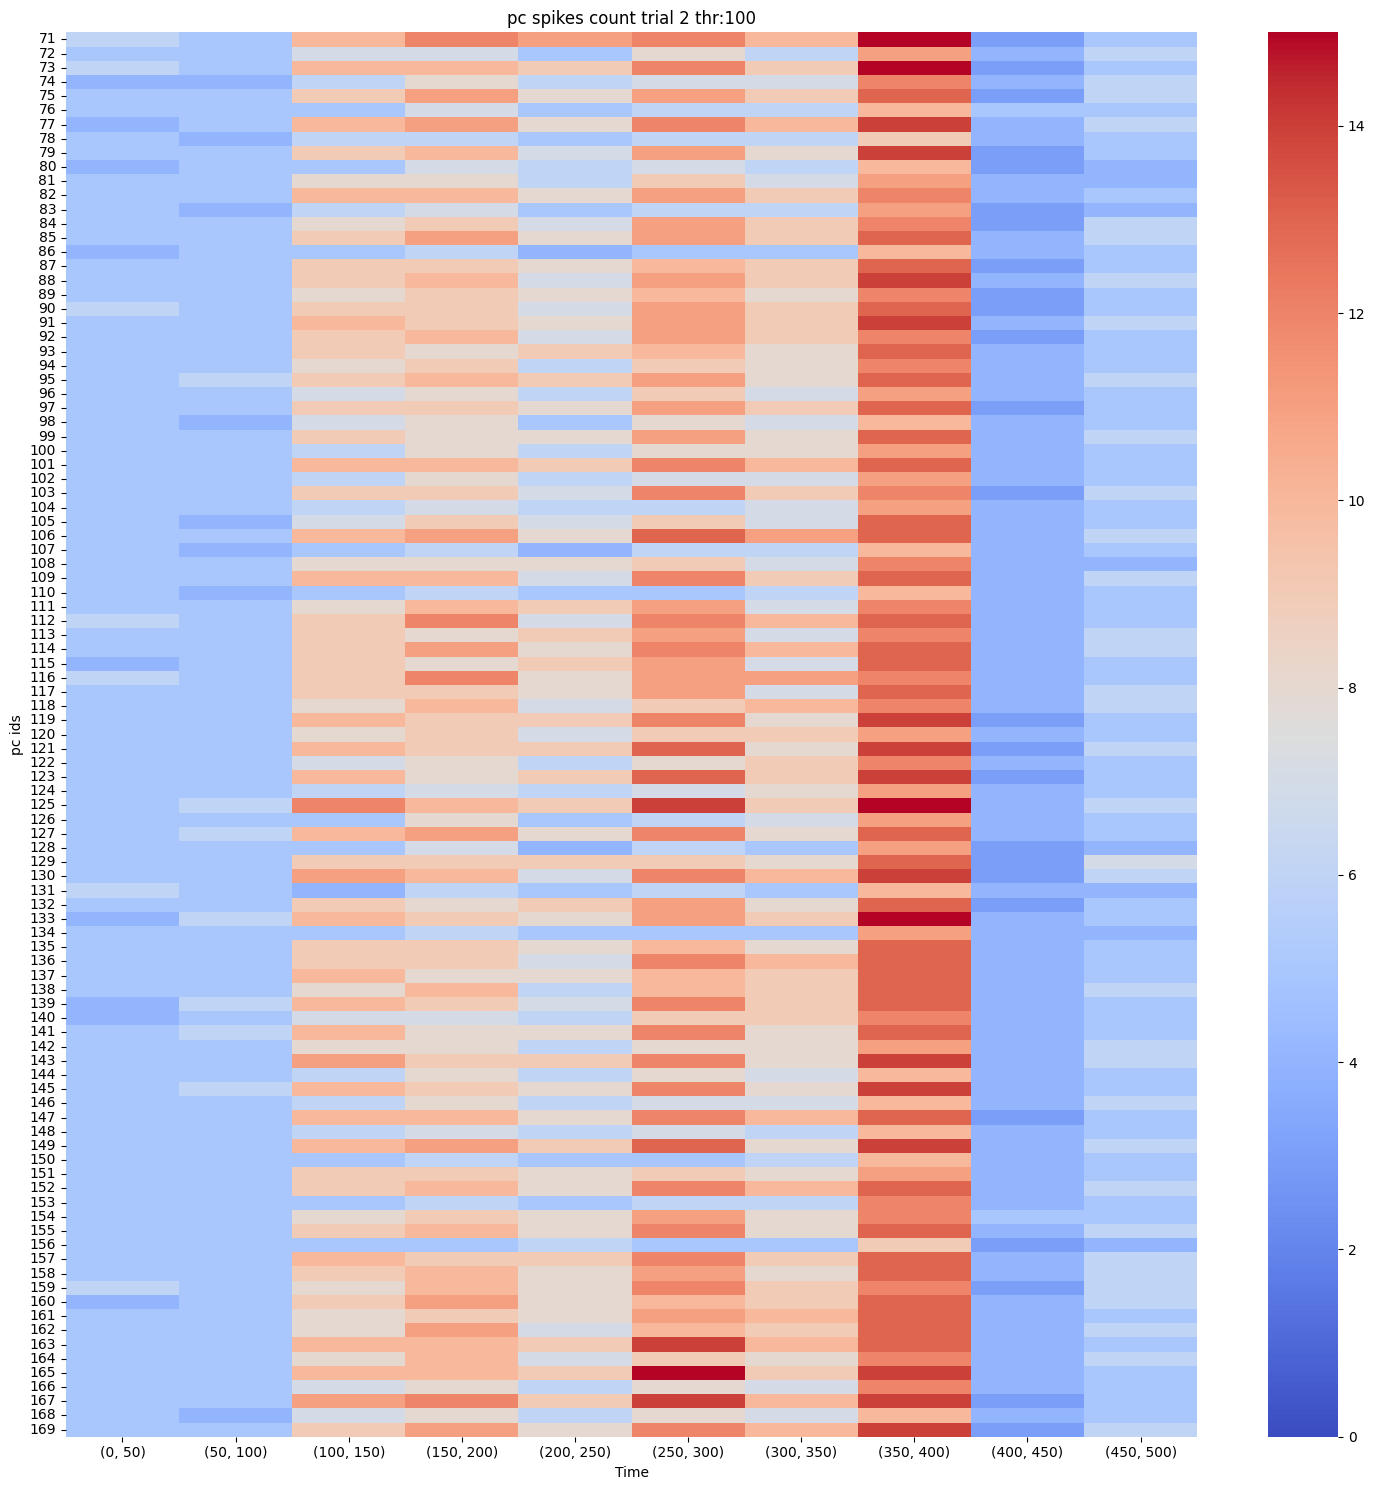

In [21]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_2_100, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 2 thr:100')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_2_thr100')

/tmp/ipykernel_219130/3090656545.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


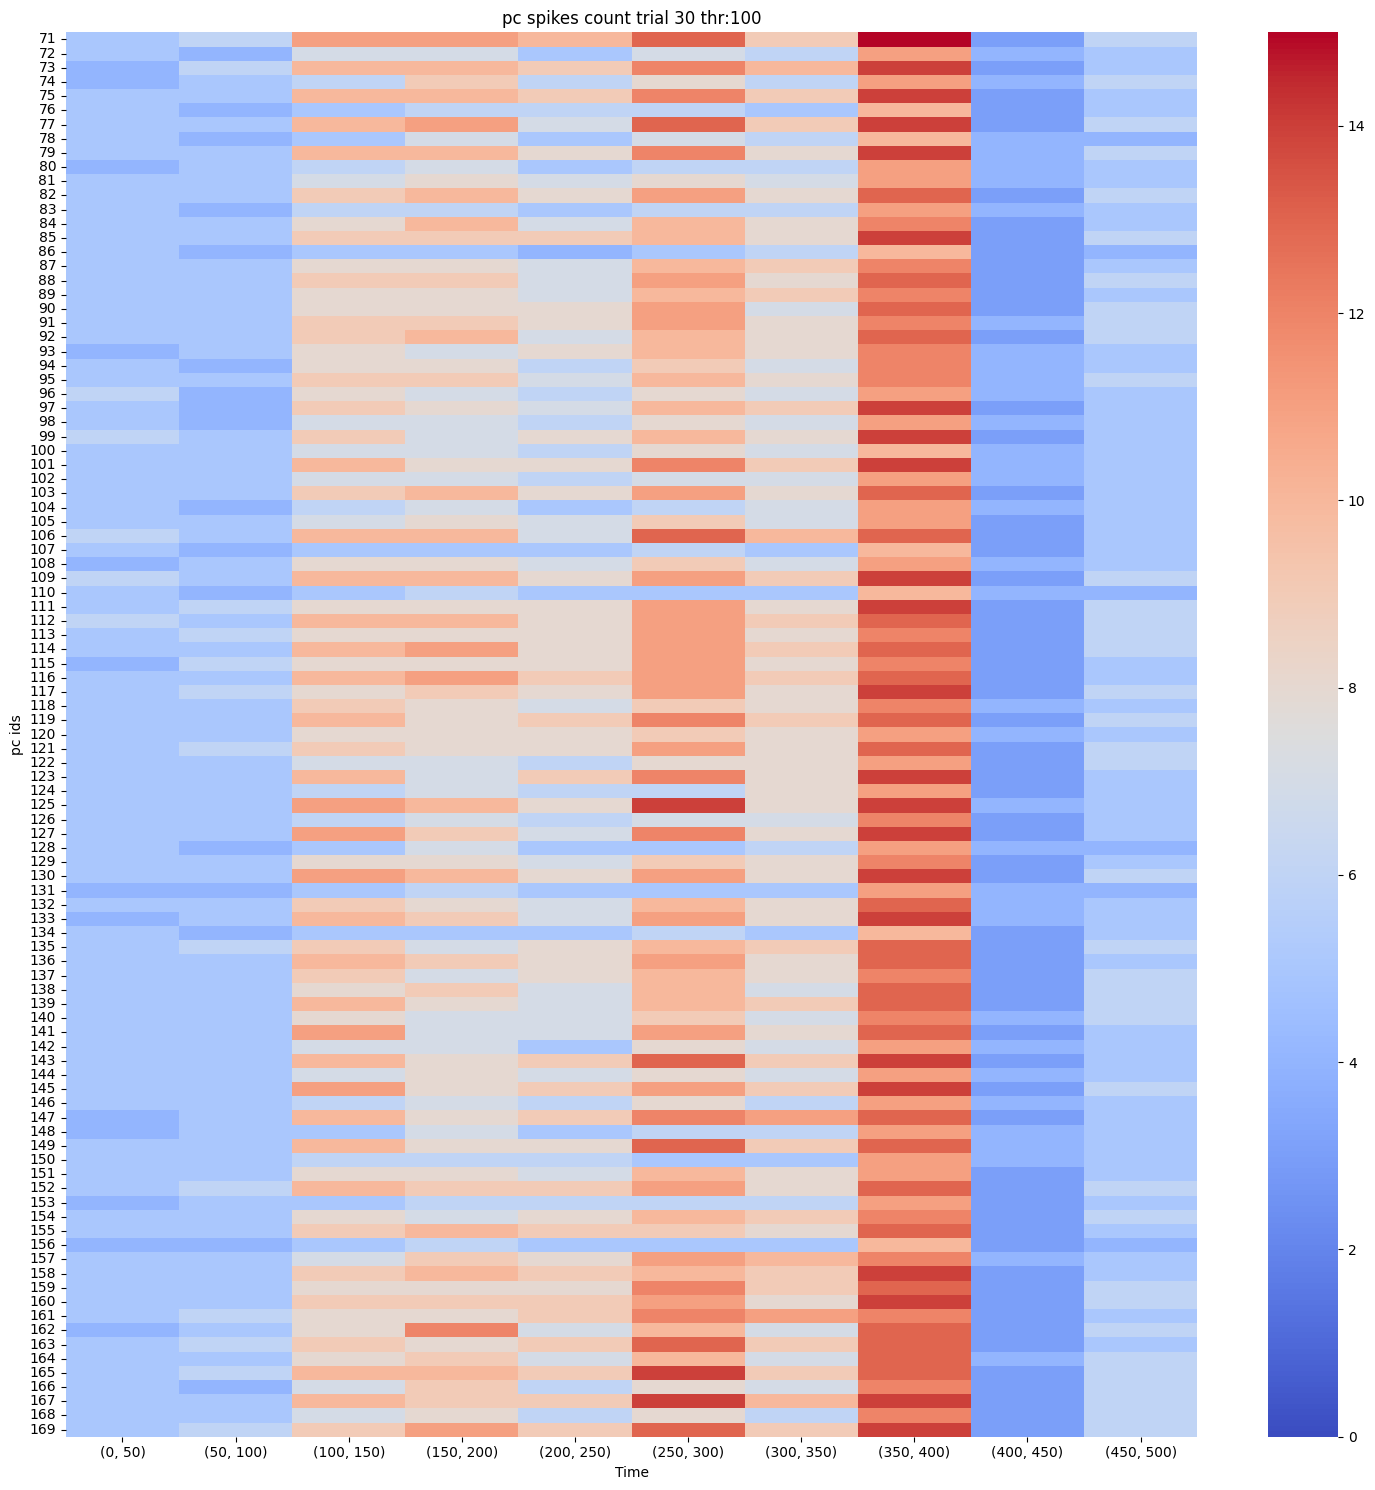

In [22]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_30_100, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 30 thr:100')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_2_thr100')

/tmp/ipykernel_219130/904552688.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


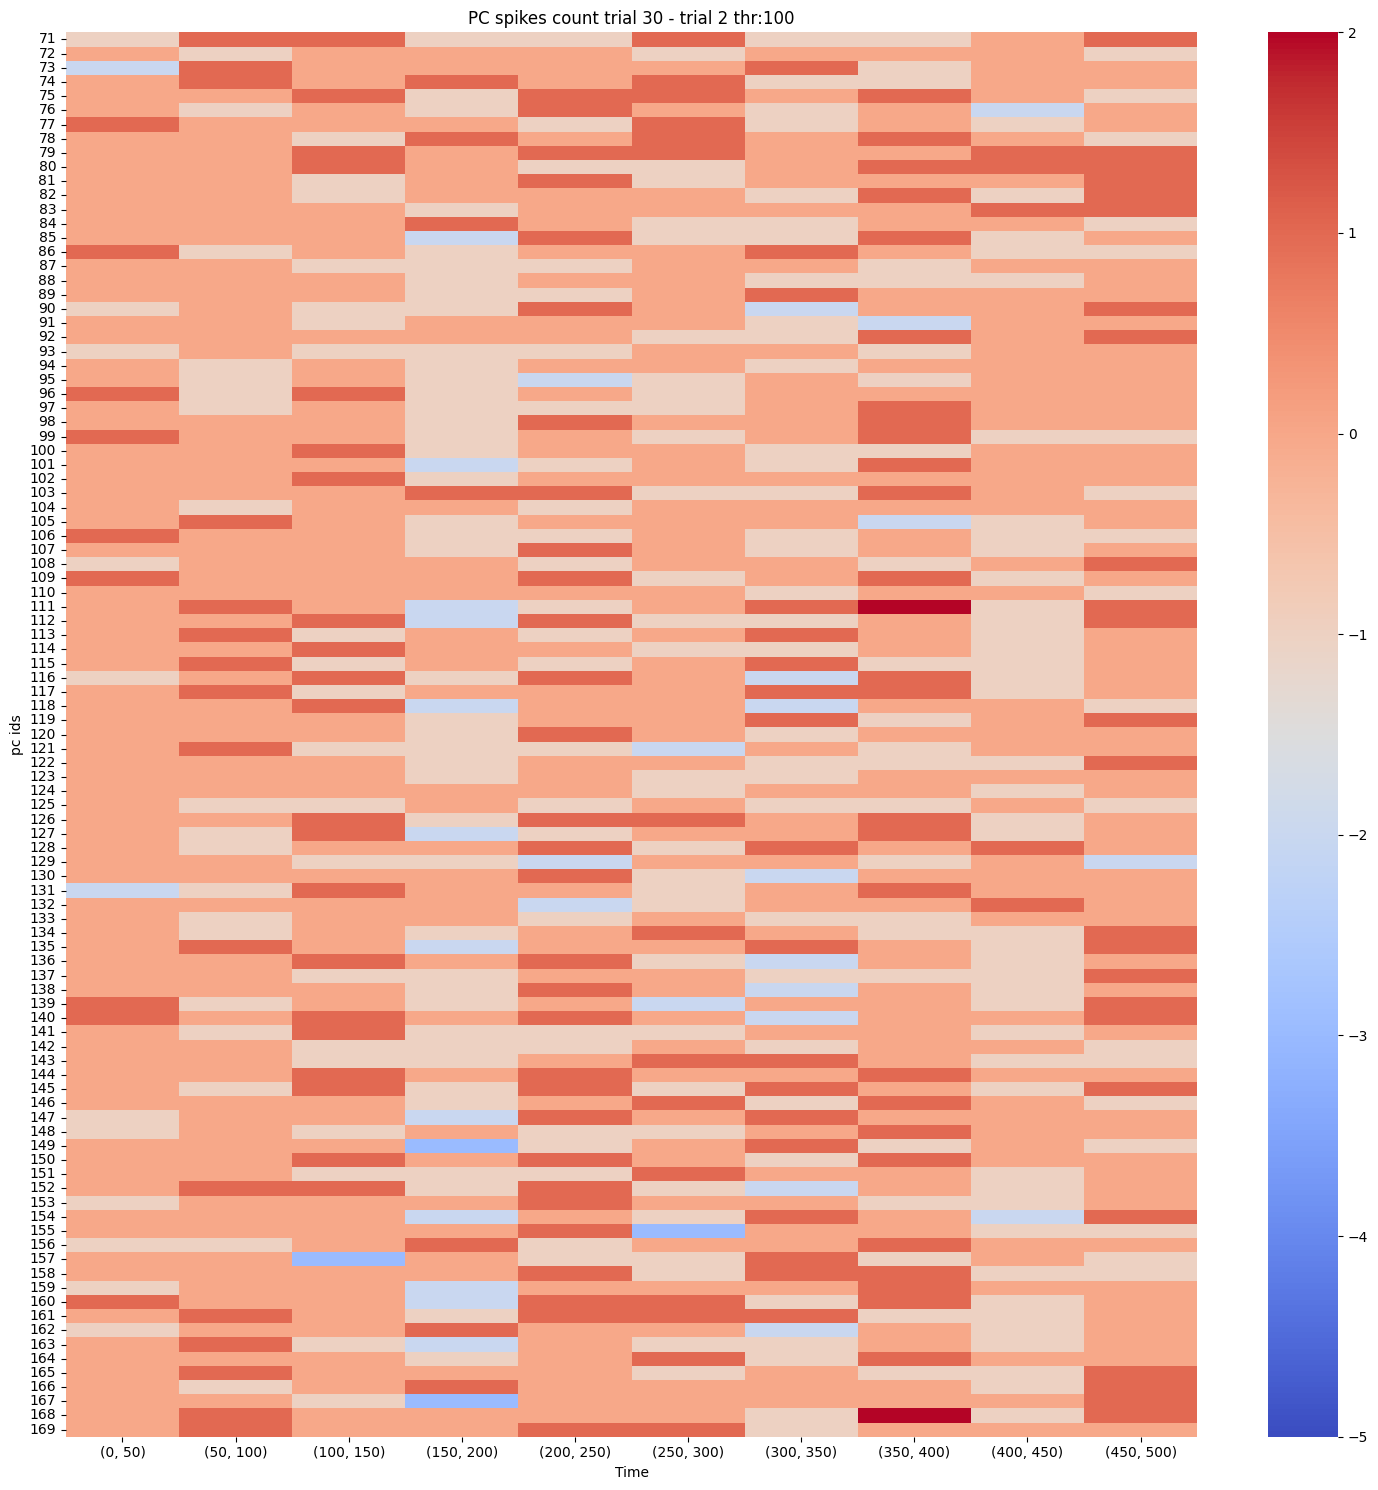

In [23]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_diff_100, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = -5,
            vmax = 2
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count trial 30 - trial 2 thr:100' )
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff_thr100')

In [24]:
pc_change_100 = np.zeros((len(pc_ids),3))
for i in range(3):
    pc_change_100[:,i] = pc_spikes_matrix_trial_diff_100[:,5]-pc_spikes_matrix_trial_diff_100[:,2+i]

pc_change_median_100 = pc_spikes_matrix_trial_diff_100[:,5] - np.median(pc_spikes_matrix_trial_diff_100[:,2:5], axis =1)
pc_change_cr_bs_100 = pc_spikes_matrix_trial_diff_100[:,5] - pc_spikes_matrix_trial_diff_100[:,3]

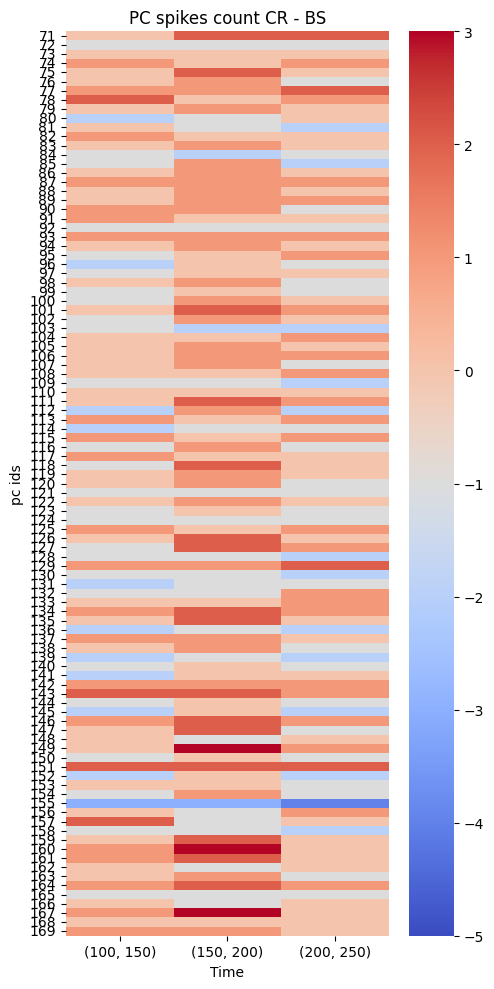

In [25]:
plt.figure(figsize=(5,10))
sns.heatmap(pc_change_100, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(100,250,time_bin)], 
            yticklabels=pc_ids,
            vmin = -5,
            vmax = 3
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count CR - BS')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff')

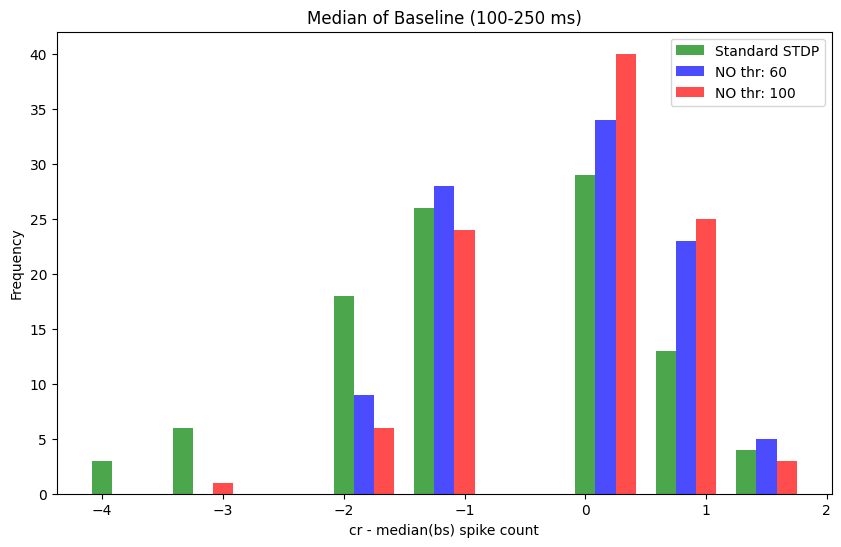

In [26]:
bins = np.linspace(-4, 2, 10)  # Adjust range and number of bins as needed

# Compute histogram values
hist1, _ = np.histogram(pc_change_median, bins=bins)
hist2, _ = np.histogram(pc_change_median_60, bins=bins)
hist3, _ = np.histogram(pc_change_median_100, bins=bins)

# Define the width of each bar
bar_width = (bins[1] - bins[0]) / 4  # Divide bin width to create space for 3 bars

# Define bar positions
positions1 = bins[:-1]  # First bar at original positions
positions2 = positions1 + bar_width  # Second bar shifted right
positions3 = positions1 + 2 * bar_width  # Third bar shifted further

# Plot each histogram as bars
plt.figure(figsize=(10, 6))
plt.bar(positions1, hist1, width=bar_width, alpha=0.7, label='Standard STDP', color='g')
plt.bar(positions2, hist2, width=bar_width, alpha=0.7, label='NO thr: 60', color='b')
plt.bar(positions3, hist3, width=bar_width, alpha=0.7, label='NO thr: 100', color='r')

# Add labels and legend
plt.xlabel('cr - median(bs) spike count')
plt.ylabel('Frequency')
plt.title('Median of Baseline (100-250 ms)')
plt.legend()
plt.show()

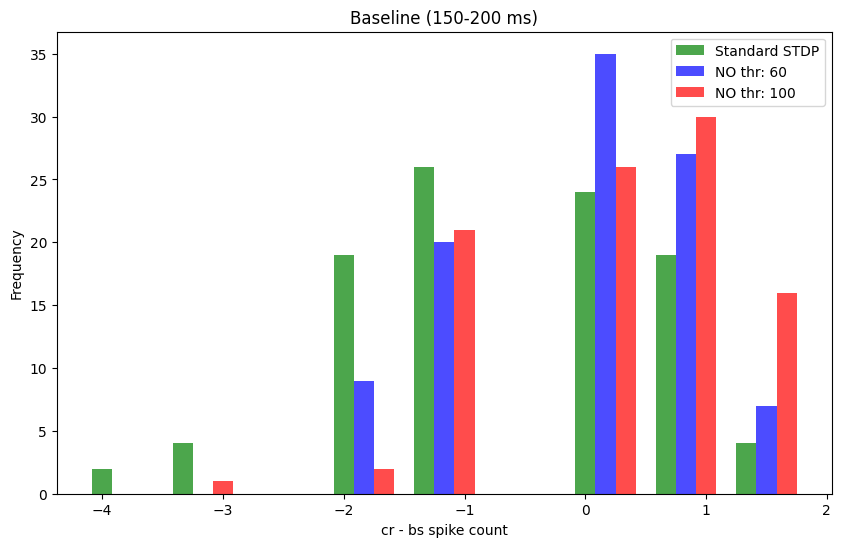

In [27]:
bins = np.linspace(-4, 2, 10)  # Adjust range and number of bins as needed

# Compute histogram values
hist1, _ = np.histogram(pc_change_cr_bs, bins=bins)
hist2, _ = np.histogram(pc_change_cr_bs_60, bins=bins)
hist3, _ = np.histogram(pc_change_cr_bs_100, bins=bins)

# Define the width of each bar
bar_width = (bins[1] - bins[0]) / 4  # Divide bin width to create space for 3 bars

# Define bar positions
positions1 = bins[:-1]  # First bar at original positions
positions2 = positions1 + bar_width  # Second bar shifted right
positions3 = positions1 + 2 * bar_width  # Third bar shifted further

# Plot each histogram as bars
plt.figure(figsize=(10, 6))
plt.bar(positions1, hist1, width=bar_width, alpha=0.7, label='Standard STDP', color='g')
plt.bar(positions2, hist2, width=bar_width, alpha=0.7, label='NO thr: 60', color='b')
plt.bar(positions3, hist3, width=bar_width, alpha=0.7, label='NO thr: 100', color='r')

# Add labels and legend
plt.xlabel('cr - bs spike count')
plt.ylabel('Frequency')
plt.title('Baseline (150-200 ms)')
plt.legend()
plt.show()

In [28]:
import pickle
with open("/home/csartor1/code/NODS/data/pfs-PC_CS.pkl", 'rb') as file:
    pfs_PC_CS = pickle.load(file)

num_syn = np.zeros((len(pc_ids)))
for pf_PC in pfs_PC_CS:
    pc_ind = np.where(pc_ids == pf_PC[1])[0]
    num_syn[pc_ind] += 1


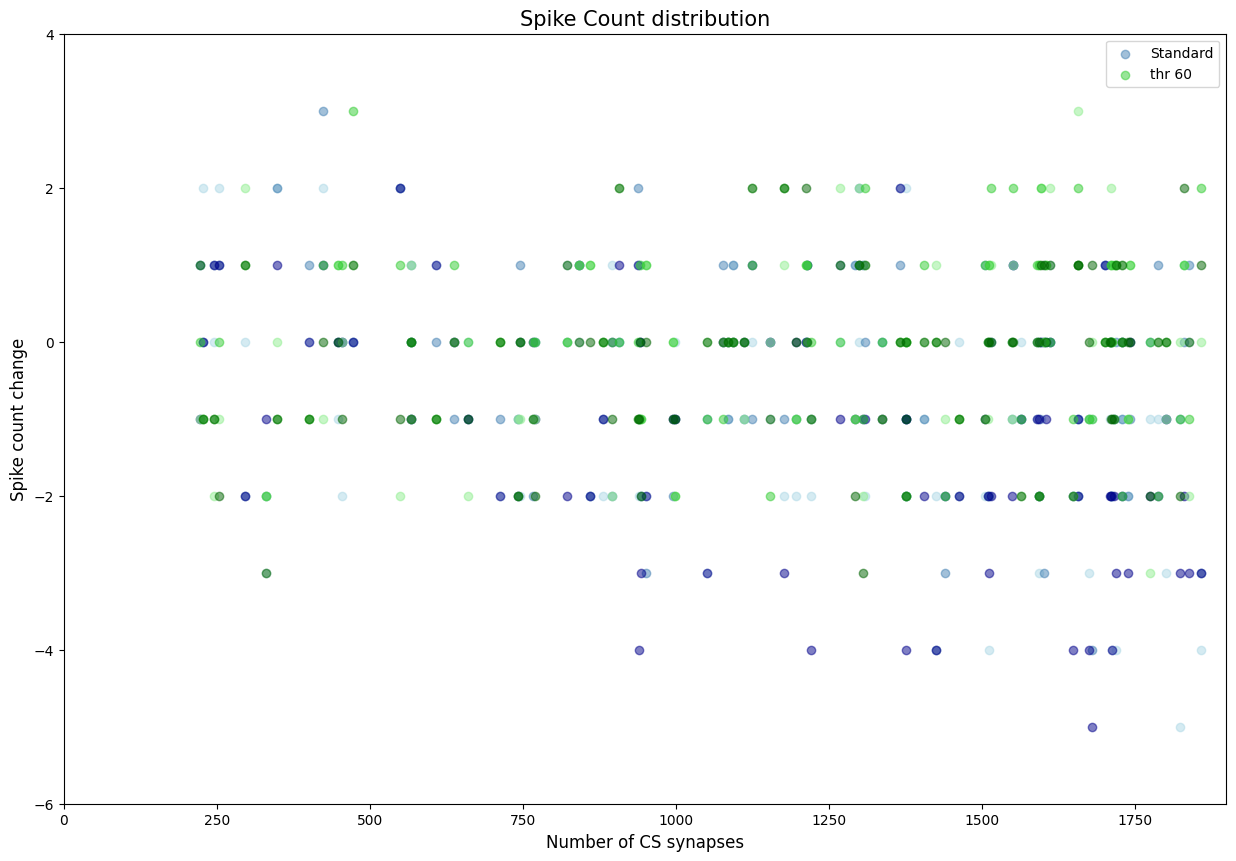

In [29]:
plt.figure(figsize=(15,10))

plt.scatter(num_syn, pc_change[:,0], color = '#ADD8E6', alpha = 0.5)
plt.scatter(num_syn, pc_change[:,1], color = '#4682B4', alpha = 0.5, label = 'Standard')
plt.scatter(num_syn, pc_change[:,2], color = '#00008B', alpha = 0.5)

plt.scatter(num_syn, pc_change_60[:,0], color = '#90EE90', alpha = 0.5)
plt.scatter(num_syn, pc_change_60[:,1], color = '#32CD32', alpha = 0.5, label = 'thr 60')
plt.scatter(num_syn, pc_change_60[:,2], color = '#006400', alpha = 0.5)

plt.legend()
plt.xlabel('Number of CS synapses', fontsize = 12)
plt.ylabel('Spike count change', fontsize = 12)
plt.title('Spike Count distribution', fontsize = 15)
plt.ylim((-6,4))
plt.xlim((0,1900))
plt.show()


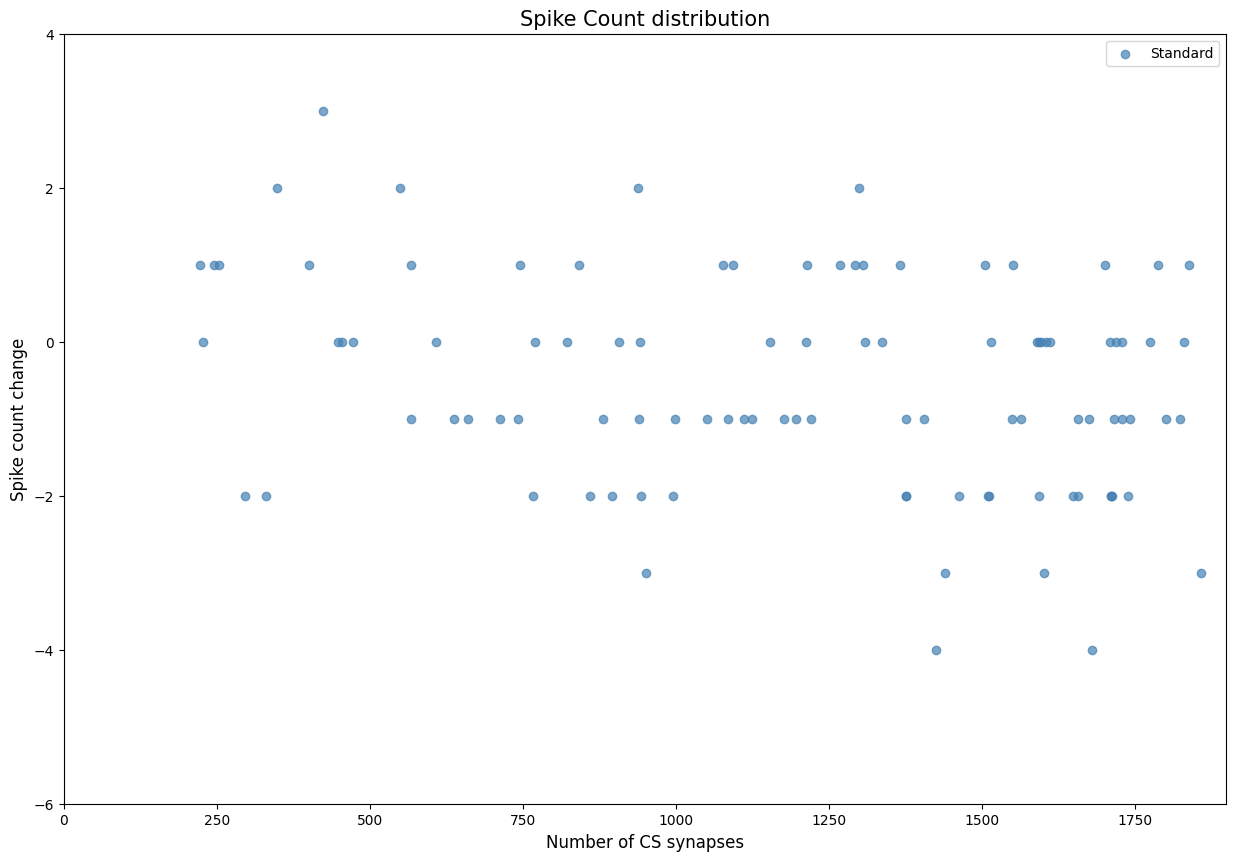

In [30]:
plt.figure(figsize=(15,10))
plt.scatter(num_syn, pc_change[:,1], color = '#4682B4', alpha = 0.7, label = 'Standard')

#plt.scatter(num_syn, pc_change_60[:,1], color = '#32CD32', alpha = 0.7, label = 'thr 60')

plt.legend()
plt.xlabel('Number of CS synapses', fontsize = 12)
plt.ylabel('Spike count change', fontsize = 12)
plt.title('Spike Count distribution', fontsize = 15)
plt.ylim((-6,4))
plt.xlim((0,1900))
plt.show()

/tmp/ipykernel_219130/746453482.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Plasticity", y="Spike Count Delta", data=data, palette={"Standard STDP": "blue", "NO STDP": "green"})


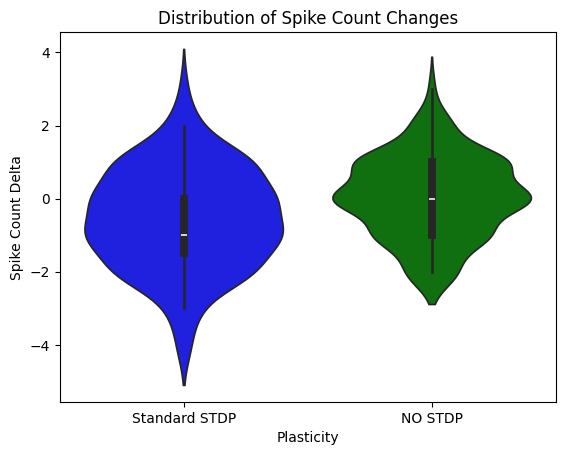

In [31]:
import seaborn as sns
# Combine data for seaborn
data = {
    "Plasticity": ['Standard STDP'] * len(pc_change[:,1]) + ['NO STDP'] * len(pc_change_60[:,1]),
    "Spike Count Delta": np.concatenate([pc_change[:,1], pc_change_60[:,1]]),
}

sns.violinplot(x="Plasticity", y="Spike Count Delta", data=data, palette={"Standard STDP": "blue", "NO STDP": "green"})
plt.title('Distribution of Spike Count Changes')
plt.show()

In [32]:
from scipy.stats import pearsonr

# Correlation for Group 1
r1, p1 = pearsonr(num_syn, pc_change[:,1])
print(f'Standard STDP Correlation: r={r1:.2f}, p={p1:.2e}')

# Correlation for Group 2
r2, p2 = pearsonr(num_syn, pc_change_60[:,1])
print(f'NO STDP Correlation: r={r2:.2f}, p={p2:.2e}')

Standard STDP Correlation: r=-0.28, p=4.52e-03
NO STDP Correlation: r=0.05, p=5.97e-01


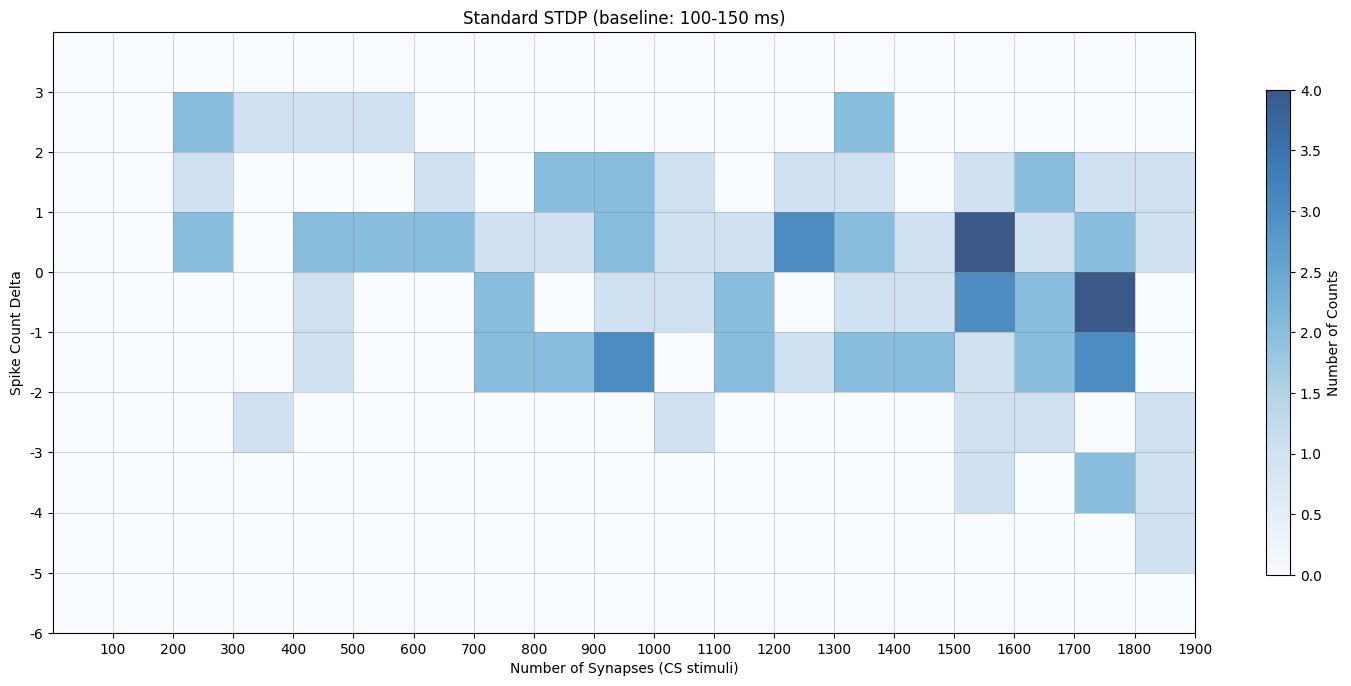

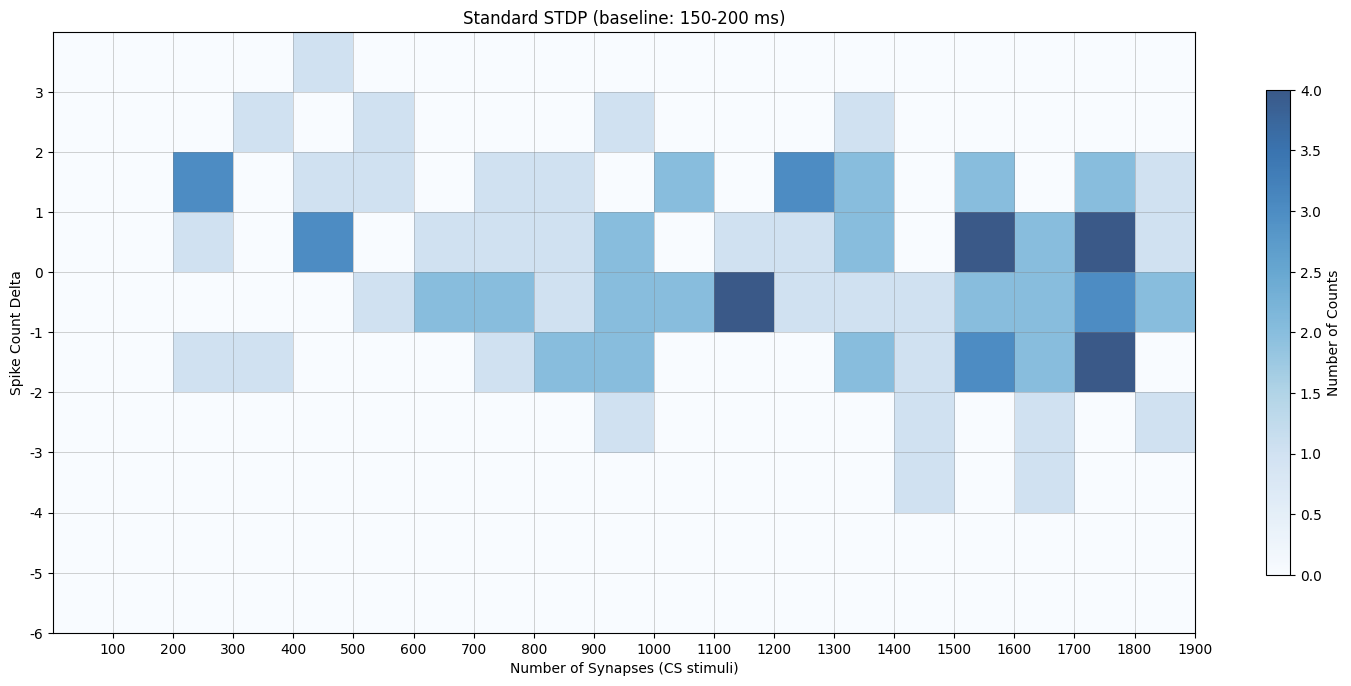

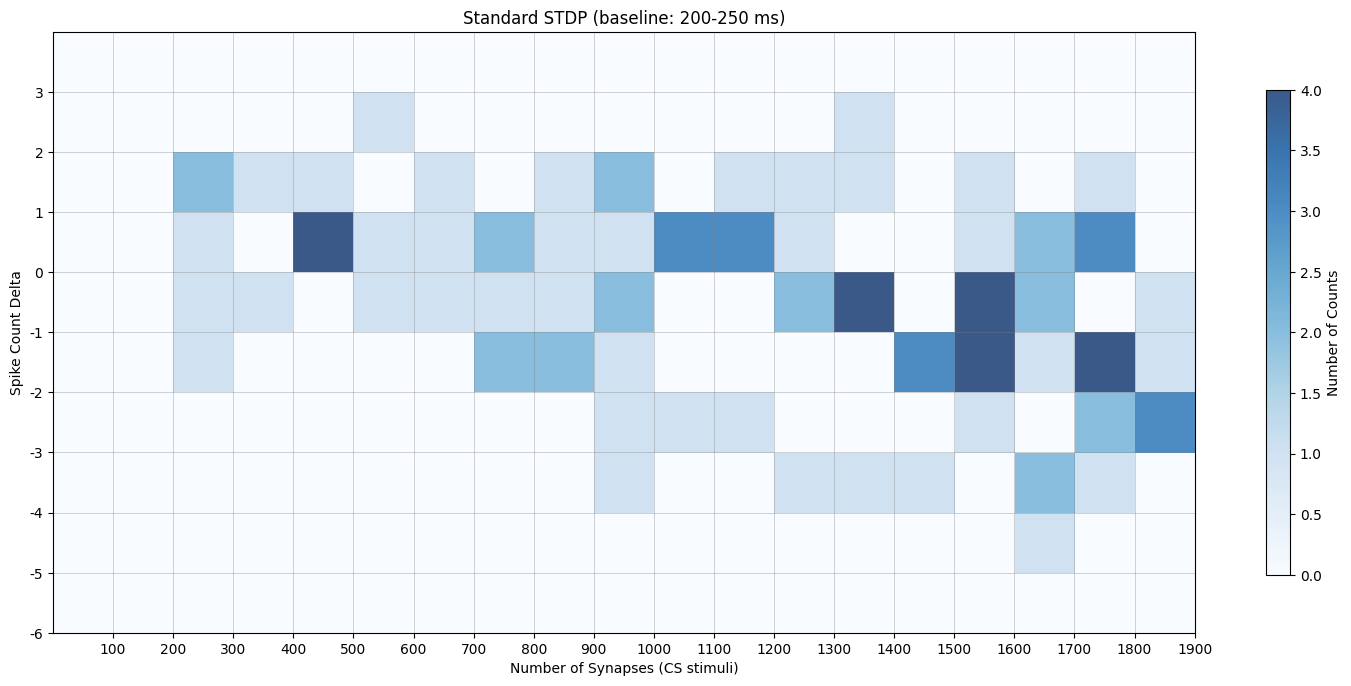

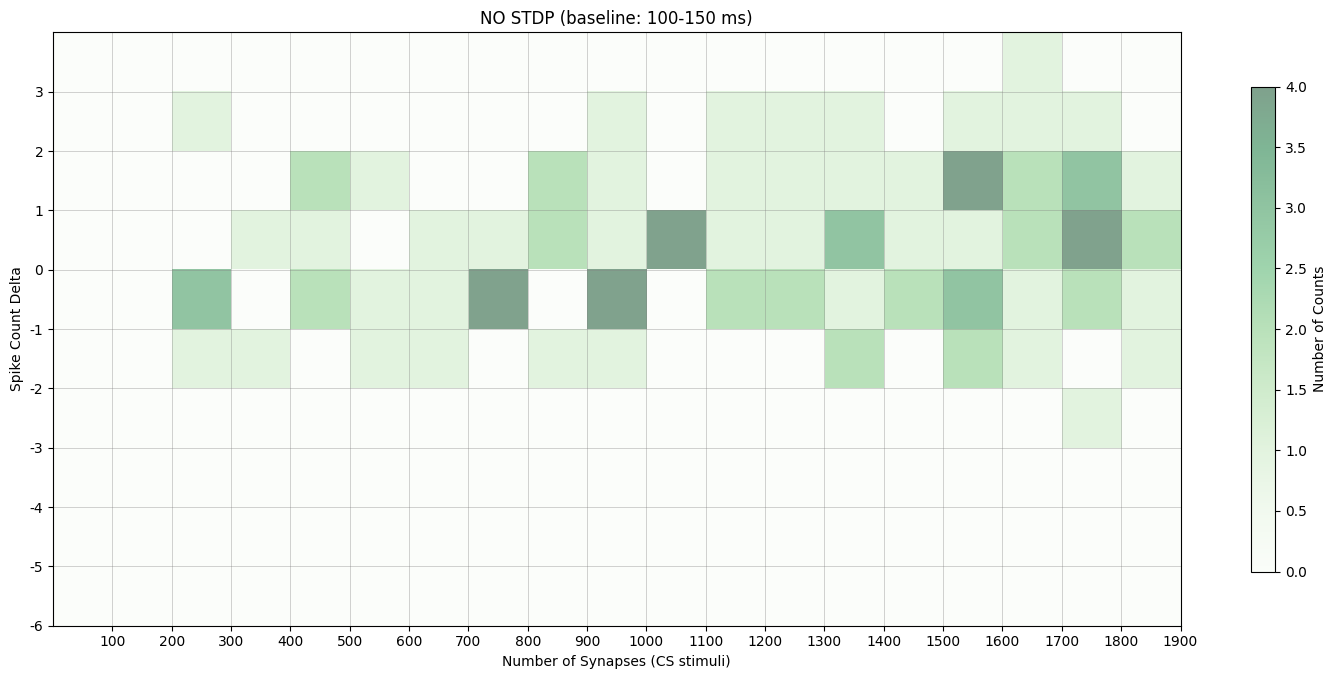

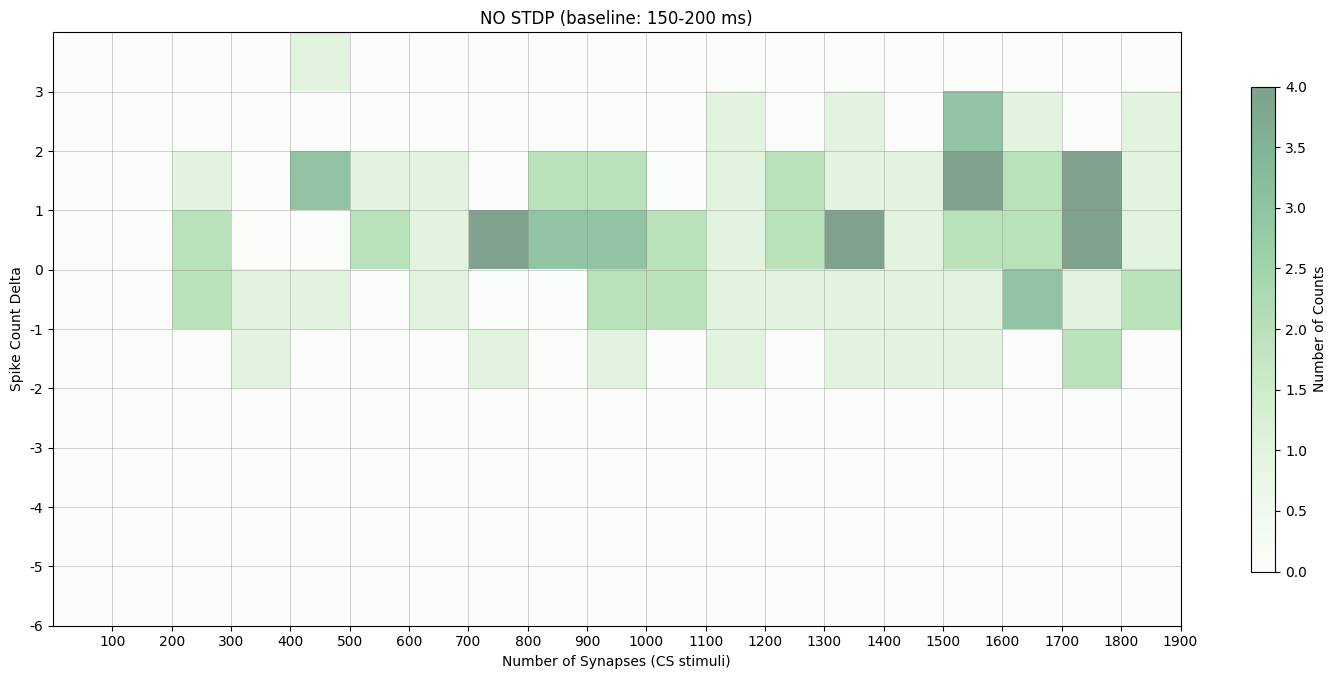

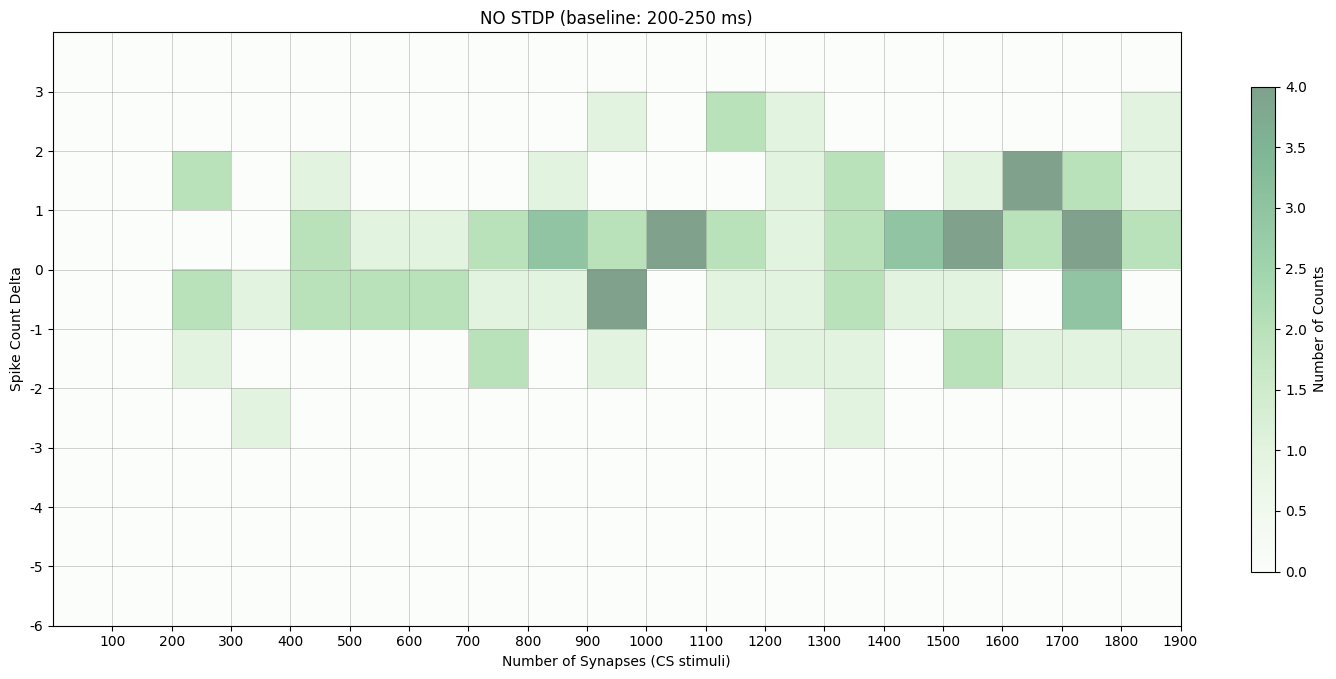

In [33]:
syn_bins = np.arange(0, 2000, 100)
delta_bins = np.arange(-6, 5, 1)
reversed_delta_bins = delta_bins[::-1]
delta_time = [(100,150),(150,200),(200,250)]

for i,times in enumerate(delta_time):
    plt.figure(figsize=(15, 10))
    matrix = np.zeros((len(delta_bins) - 1, len(syn_bins) - 1))
    for synapses, spike_delta in zip(num_syn, pc_change[:,i]):
        synapse_bin_idx = np.digitize(synapses, syn_bins) - 1  # Synapse bin index
        delta_bin_idx = np.digitize(spike_delta, delta_bins) - 1  # Spike delta bin index
        
        if (0 <= synapse_bin_idx < len(syn_bins) - 1) and (0 <= delta_bin_idx < len(delta_bins) - 1):
            # Assign a value (use count or another aggregation if needed)
            matrix[delta_bin_idx, synapse_bin_idx] += 1

    # Create the heatmap
    matrix = np.flipud(matrix)
    plt.imshow(matrix, cmap='Blues', alpha=0.8, label='Standard STDP', vmax=4, vmin = 0)
    plt.colorbar(label='Number of Counts', shrink=0.5)
    plt.xticks(ticks=np.arange(0.5, len(syn_bins)-1, 1),labels=syn_bins[1:])
    plt.yticks(ticks=np.arange(0.5, len(delta_bins)-1, 1),labels=reversed_delta_bins[1:])
    plt.title(f'Standard STDP (baseline: {times[0]}-{times[1]} ms)')
    plt.xlabel('Number of Synapses (CS stimuli)')
    plt.ylabel('Spike Count Delta')
    plt.grid(color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    plt.tight_layout()
    #plt.colorbar(label='Number of Counts', shrink=0.5)
    plt.show()

for i,times in enumerate(delta_time):
    plt.figure(figsize=(15, 10))
    matrix = np.zeros((len(delta_bins) - 1, len(syn_bins) - 1))
    for synapses, spike_delta in zip(num_syn, pc_change_60[:,i]):
        synapse_bin_idx = np.digitize(synapses, syn_bins) - 1  # Synapse bin index
        delta_bin_idx = np.digitize(spike_delta, delta_bins) - 1  # Spike delta bin index
        
        if (0 <= synapse_bin_idx < len(syn_bins) - 1) and (0 <= delta_bin_idx < len(delta_bins) - 1):
            # Assign a value (use count or another aggregation if needed)
            matrix[delta_bin_idx, synapse_bin_idx] += 1

    matrix = np.flipud(matrix)
    plt.imshow(matrix, cmap='Greens', alpha=0.5, label='NO-STDP', vmax=4, vmin = 0)
    plt.xticks(ticks=np.arange(0.5, len(syn_bins)-1, 1),labels=syn_bins[1:])
    plt.yticks(ticks=np.arange(0.5, len(delta_bins)-1, 1),labels=reversed_delta_bins[1:])
    plt.title(f'NO STDP (baseline: {times[0]}-{times[1]} ms)')
    plt.xlabel('Number of Synapses (CS stimuli)')
    plt.ylabel('Spike Count Delta')
    plt.grid(color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.colorbar(label='Number of Counts', shrink=0.5)
    plt.show()

In [69]:
n_CS_device = 117
burst_time = CS_burst_dur/n_CS_device
CS_f_rate = 40
CS_n_spikes = int(CS_f_rate * burst_time / 1000)
CS_spikes = []
delta = 2

np.random.seed(42)
for sg in range(n_CS_device - 1):
    t0 = (CS_start_first+sg*burst_time)-delta
    tf = CS_start_first + (sg+1)*burst_time + delta
    random_spikes = np.random.uniform(low=t0, high=tf, size=5)
    CS_matrix_start = np.round(np.sort(np.unique(random_spikes)))
    CS_matrix = np.concatenate(
        [CS_matrix_start + 500 * t for t in range(30)]
    )
    CS_spikes.append(CS_matrix)



In [70]:
CS_spikes

[array([   99.,   100.,   102.,   103.,   104.,   599.,   600.,   602.,
          603.,   604.,  1099.,  1100.,  1102.,  1103.,  1104.,  1599.,
         1600.,  1602.,  1603.,  1604.,  2099.,  2100.,  2102.,  2103.,
         2104.,  2599.,  2600.,  2602.,  2603.,  2604.,  3099.,  3100.,
         3102.,  3103.,  3104.,  3599.,  3600.,  3602.,  3603.,  3604.,
         4099.,  4100.,  4102.,  4103.,  4104.,  4599.,  4600.,  4602.,
         4603.,  4604.,  5099.,  5100.,  5102.,  5103.,  5104.,  5599.,
         5600.,  5602.,  5603.,  5604.,  6099.,  6100.,  6102.,  6103.,
         6104.,  6599.,  6600.,  6602.,  6603.,  6604.,  7099.,  7100.,
         7102.,  7103.,  7104.,  7599.,  7600.,  7602.,  7603.,  7604.,
         8099.,  8100.,  8102.,  8103.,  8104.,  8599.,  8600.,  8602.,
         8603.,  8604.,  9099.,  9100.,  9102.,  9103.,  9104.,  9599.,
         9600.,  9602.,  9603.,  9604., 10099., 10100., 10102., 10103.,
        10104., 10599., 10600., 10602., 10603., 10604., 11099., 

In [40]:
burst_time

2.393162393162393